# Lượng mưa theo ngày, tuần và tháng trong năm
Sử dụng toàn bộ dữ liệu mưa hiện có. Mỗi biểu đồ thể hiện tổng lượng mưa trong một ngày, tuần hoặc tháng, được lấy trung bình giữa các trạm và các năm có dữ liệu. Các khoảng thời gian chưa đủ ngày vẫn được tính theo số liệu hiện có.


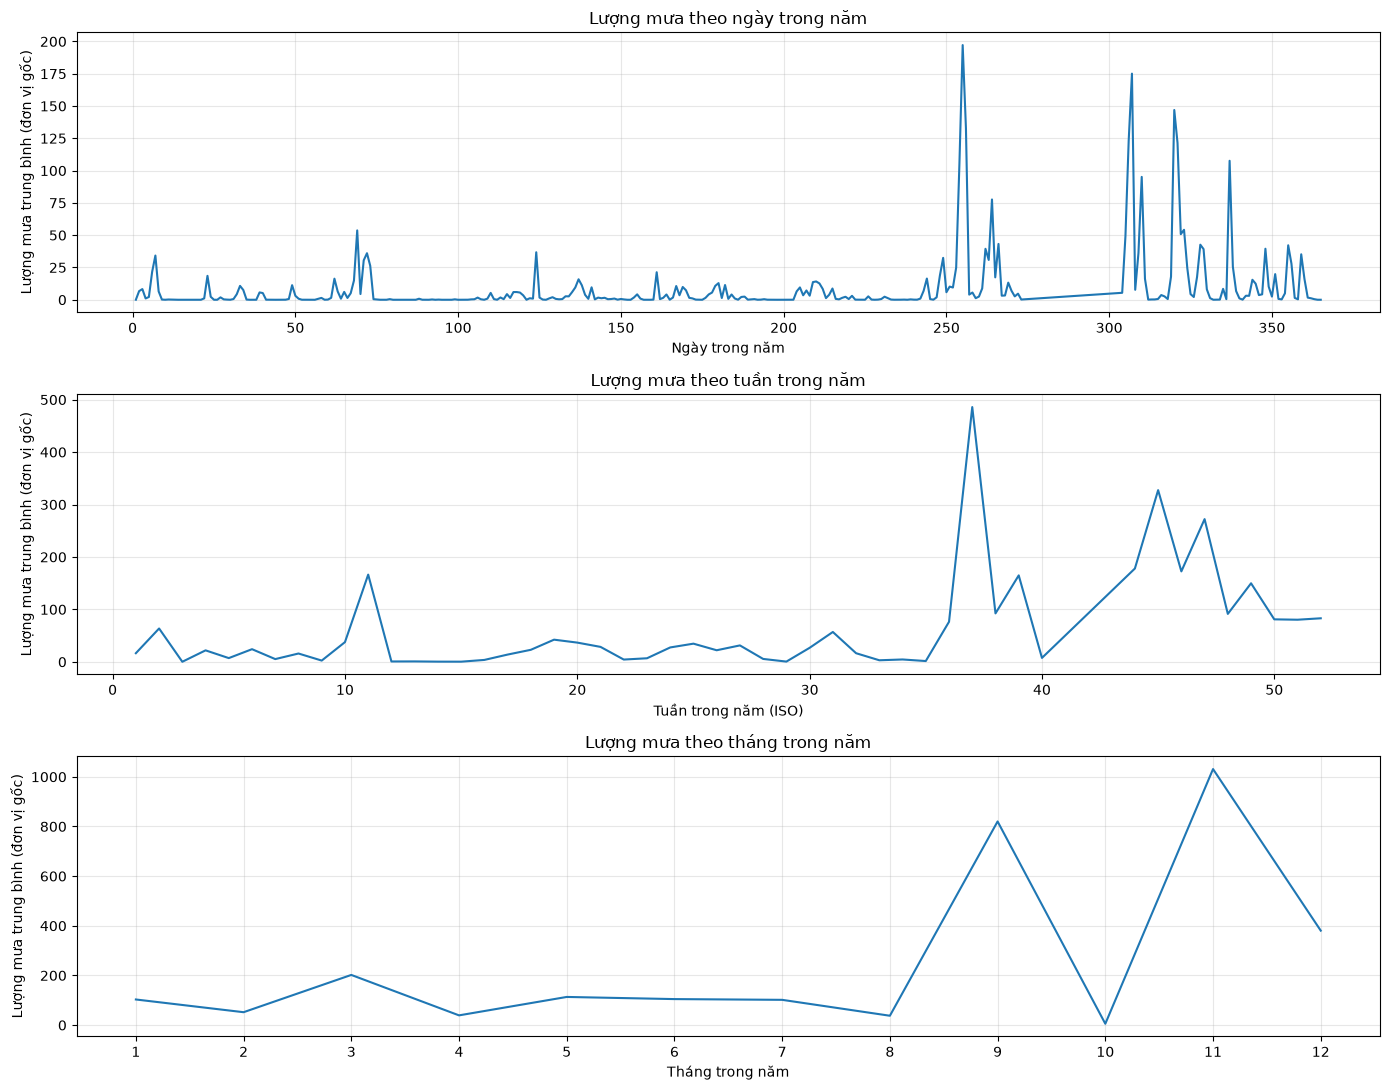

In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Đọc toàn bộ dữ liệu mưa của các trạm tại Huế.
data_dir = Path("../data") if Path("../data").is_dir() else Path("data")
rain = pd.read_csv(
    data_dir / "rain_observations.csv.gz",
    usecols=["station_id", "depth", "time_point"],
)
rain["time"] = pd.to_datetime(rain["time_point"], utc=True).dt.tz_convert("Asia/Bangkok")
rain["depth"] = pd.to_numeric(rain["depth"], errors="coerce")
rain["year"] = rain["time"].dt.year
rain["day"] = rain["time"].dt.dayofyear
rain["month"] = rain["time"].dt.month
iso_calendar = rain["time"].dt.isocalendar()
rain["week_year"] = iso_calendar.year
rain["week"] = iso_calendar.week

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
periods = [
    ("day", "year", "Ngày trong năm", "Lượng mưa theo ngày trong năm"),
    ("week", "week_year", "Tuần trong năm (ISO)", "Lượng mưa theo tuần trong năm"),
    ("month", "year", "Tháng trong năm", "Lượng mưa theo tháng trong năm"),
]

for ax, (period, year, xlabel, title) in zip(axes, periods):
    # Cộng lượng mưa của từng trạm trong mỗi ngày/tuần/tháng.
    # Sau đó lấy trung bình giữa các trạm và các năm có dữ liệu.
    totals = rain.groupby([year, "station_id", period])["depth"].sum(min_count=1)
    average_rain = totals.groupby(level=period).mean()

    ax.plot(average_rain.index, average_rain.values, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Lượng mưa trung bình (đơn vị gốc)")
    ax.grid(alpha=0.3)
    if period == "month":
        ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


## Lượng mưa và mực nước Dã Viên theo ngày
Cột xanh là tổng mưa ngày trung bình giữa các trạm tại Huế; đường đỏ là mực nước trung bình ngày tại Dã Viên. Hai đại lượng dùng hai trục tung riêng và được ghép theo ngày thực tế, không gộp các năm. Ngày đầu/cuối có thể chỉ có một phần dữ liệu.


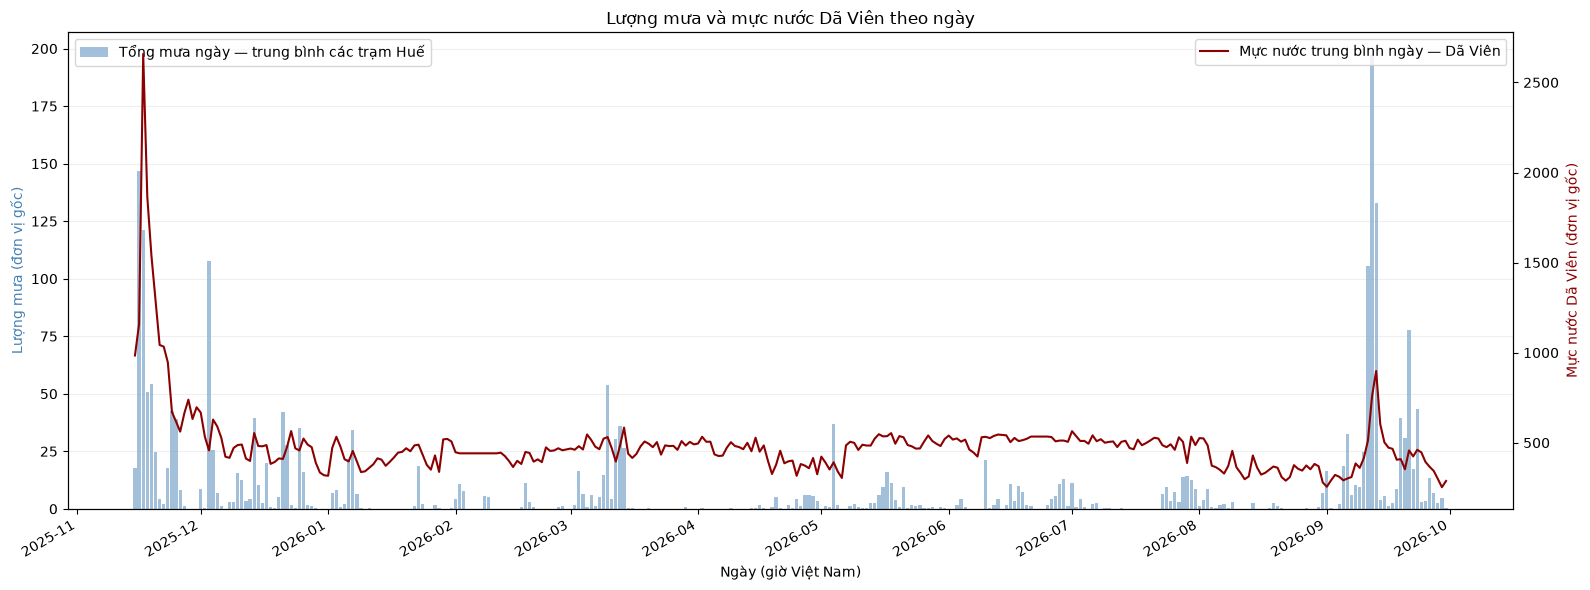

In [41]:
# Chạy sau cell đọc dữ liệu mưa ở trên.
water = pd.read_csv(
    data_dir / "water_level_observations.csv.gz",
    usecols=["station_id", "depth", "time_point"],
    dtype={"station_id": str},
)
# Mã trạm Dã Viên; bỏ các số 0 ở đầu mã để đối chiếu.
water = water[water["station_id"].str.lstrip("0").eq("74647403")].copy()
water["time"] = pd.to_datetime(water["time_point"], utc=True).dt.tz_convert("Asia/Bangkok")
water["depth"] = pd.to_numeric(water["depth"], errors="coerce")

# Tổng mưa từng ngày tại mỗi trạm, rồi lấy trung bình giữa các trạm.
rain_daily = (
    rain.groupby([rain["time"].dt.floor("D"), "station_id"])["depth"]
    .sum(min_count=1)
    .groupby(level=0)
    .mean()
    .rename("rain")
)
# Mực nước trung bình ngày tại Dã Viên.
water_daily = (
    water.set_index("time")["depth"]
    .resample("D")
    .mean()
    .rename("water_level")
)
# Ghép theo đúng ngày, trong khoảng có dữ liệu mực nước Dã Viên.
daily = water_daily.to_frame().join(rain_daily)

fig, ax_rain = plt.subplots(figsize=(16, 6))
ax_water = ax_rain.twinx()

ax_rain.bar(
    daily.index, daily["rain"], width=0.8, color="steelblue", alpha=0.5,
    label="Tổng mưa ngày — trung bình các trạm Huế",
)
ax_water.plot(
    daily.index, daily["water_level"], color="darkred", linewidth=1.5,
    label="Mực nước trung bình ngày — Dã Viên",
)

ax_rain.set_xlabel("Ngày (giờ Việt Nam)")
ax_rain.set_ylabel("Lượng mưa (đơn vị gốc)", color="steelblue")
ax_water.set_ylabel("Mực nước Dã Viên (đơn vị gốc)", color="darkred")
ax_rain.set_title("Lượng mưa và mực nước Dã Viên theo ngày")
ax_rain.grid(axis="y", alpha=0.2)
ax_rain.legend(loc="upper left")
ax_water.legend(loc="upper right")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Tương quan mưa từng trạm và thay đổi mực nước Dã Viên
Phân tích tất cả các trạm, với 5 cửa sổ tích lũy mưa × 5 thời hạn dự báo. Tại thời điểm t, lượng mưa chỉ được cộng từ các giờ đã kết thúc; thay đổi mực nước bằng H(t + horizon) − H(t). H là mực nước trung bình của giờ vừa kết thúc. Chỉ những cặp có đủ dữ liệu được dùng để tính Pearson r.

Tương quan dương nghĩa là lượng mưa lớn đi cùng mức thay đổi mực nước cao hơn; tương quan âm nghĩa là mức thay đổi thấp hơn. Đây là mối liên hệ trong dữ liệu, không phải kết luận nhân quả. Cửa sổ mưa và horizon không phải phép đo chính xác thời gian nước di chuyển từ trạm mưa về Dã Viên.


In [42]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Đọc từng trạm riêng biệt, giữ nguyên đơn vị gốc.
data_dir = Path("../data") if Path("../data").is_dir() else Path("data")
rain_data = pd.read_csv(
    data_dir / "rain_observations.csv.gz",
    usecols=["station_id", "depth", "time_point"],
    dtype={"station_id": str},
)
water_data = pd.read_csv(
    data_dir / "water_level_observations.csv.gz",
    usecols=["station_id", "depth", "time_point"],
    dtype={"station_id": str},
)
water_data = water_data[
    water_data["station_id"].str.lstrip("0").eq("74647403")
].copy()

for frame in [rain_data, water_data]:
    frame["time"] = pd.to_datetime(frame["time_point"], utc=True).dt.tz_convert("Asia/Bangkok")
    frame["depth"] = pd.to_numeric(frame["depth"], errors="coerce")

# Mỗi mốc t chỉ tổng hợp số đo trong giờ vừa kết thúc: (t - 1 giờ, t].
# Không dùng số đo sau t để tính lượng mưa tại t.
rain_hourly = (
    rain_data.groupby([
        pd.Grouper(key="time", freq="1h", closed="right", label="right"),
        "station_id",
    ])["depth"]
    .sum(min_count=1)
    .unstack("station_id")
    .sort_index()
)
# Giữ lưới thời gian đều để rolling/shift tương ứng đúng số giờ.
rain_hourly = rain_hourly.reindex(pd.date_range(
    rain_hourly.index.min(), rain_hourly.index.max(), freq="1h"
))
water_hourly = (
    water_data.set_index("time")["depth"]
    .resample("1h", closed="right", label="right")
    .mean()
)

# Bổ sung tên trạm; trạm không có tên trong metadata vẫn được giữ lại bằng mã.
station_info = pd.read_csv(data_dir / "rain_stations.csv.gz", dtype={"code": str})
station_names = station_info.drop_duplicates("code").set_index("code")["name"].to_dict()
hours = [1, 3, 6, 12, 24]
water_changes = {
    horizon: water_hourly.shift(-horizon) - water_hourly
    for horizon in hours
}

records = []
for window in hours:
    # Cửa sổ thiếu một giờ sẽ là NaN; không xem giờ thiếu là mưa bằng 0.
    accumulated_rain = rain_hourly.rolling(window, min_periods=window).sum()
    accumulated_rain = accumulated_rain.reindex(water_hourly.index)

    for station_id in accumulated_rain.columns:
        station = f"{station_id} — {station_names.get(station_id, 'Chưa có tên trạm')}"
        for horizon in hours:
            paired = pd.concat([
                accumulated_rain[station_id].rename("rainfall"),
                water_changes[horizon].rename("delta_water_level"),
            ], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
            correlation = np.nan
            if len(paired) >= 3 and paired.nunique().min() > 1:
                correlation = paired["rainfall"].corr(paired["delta_water_level"], method="pearson")
            records.append({
                "station": station,
                "rainfall_window": window,
                "forecast_horizon": horizon,
                "correlation": correlation,
                "sample_count": len(paired),
            })

correlation_results = pd.DataFrame(records).sort_values(
    "correlation", key=lambda values: values.abs(), ascending=False, na_position="last"
).reset_index(drop=True)

print("rainfall_window và forecast_horizon có đơn vị giờ.")
print(f"Số trạm: {rain_hourly.shape[1]}; số tổ hợp: {len(correlation_results)}")
display(correlation_results.head(20).round({"correlation": 3}))


rainfall_window và forecast_horizon có đơn vị giờ.
Số trạm: 56; số tổ hợp: 1400


,station,rainfall_window,forecast_horizon,correlation,sample_count
0,750031 — Chưa có tên trạm,24,24,-0.396,4327
1,750026 — Bình Tiến (Hương Trà),24,24,-0.356,7642
2,958573 — Đập Thủy điện Rào Trăng 3 (Phong Điền),24,24,-0.321,7642
3,750061 — Thủy điện Bình Điền (Hương Trà),24,24,-0.314,7642
4,750062 — Hồng Thái (A Lưới),6,12,0.306,7648
5,750007 — Nhâm (A Lưới),6,12,0.288,7654
6,750062 — Hồng Thái (A Lưới),3,12,0.283,7651
7,750062 — Hồng Thái (A Lưới),12,12,0.277,7642
8,750007 — Nhâm (A Lưới),3,12,0.275,7654
9,750003 — Thị trấn A Lưới (A Lưới),6,12,0.274,7631


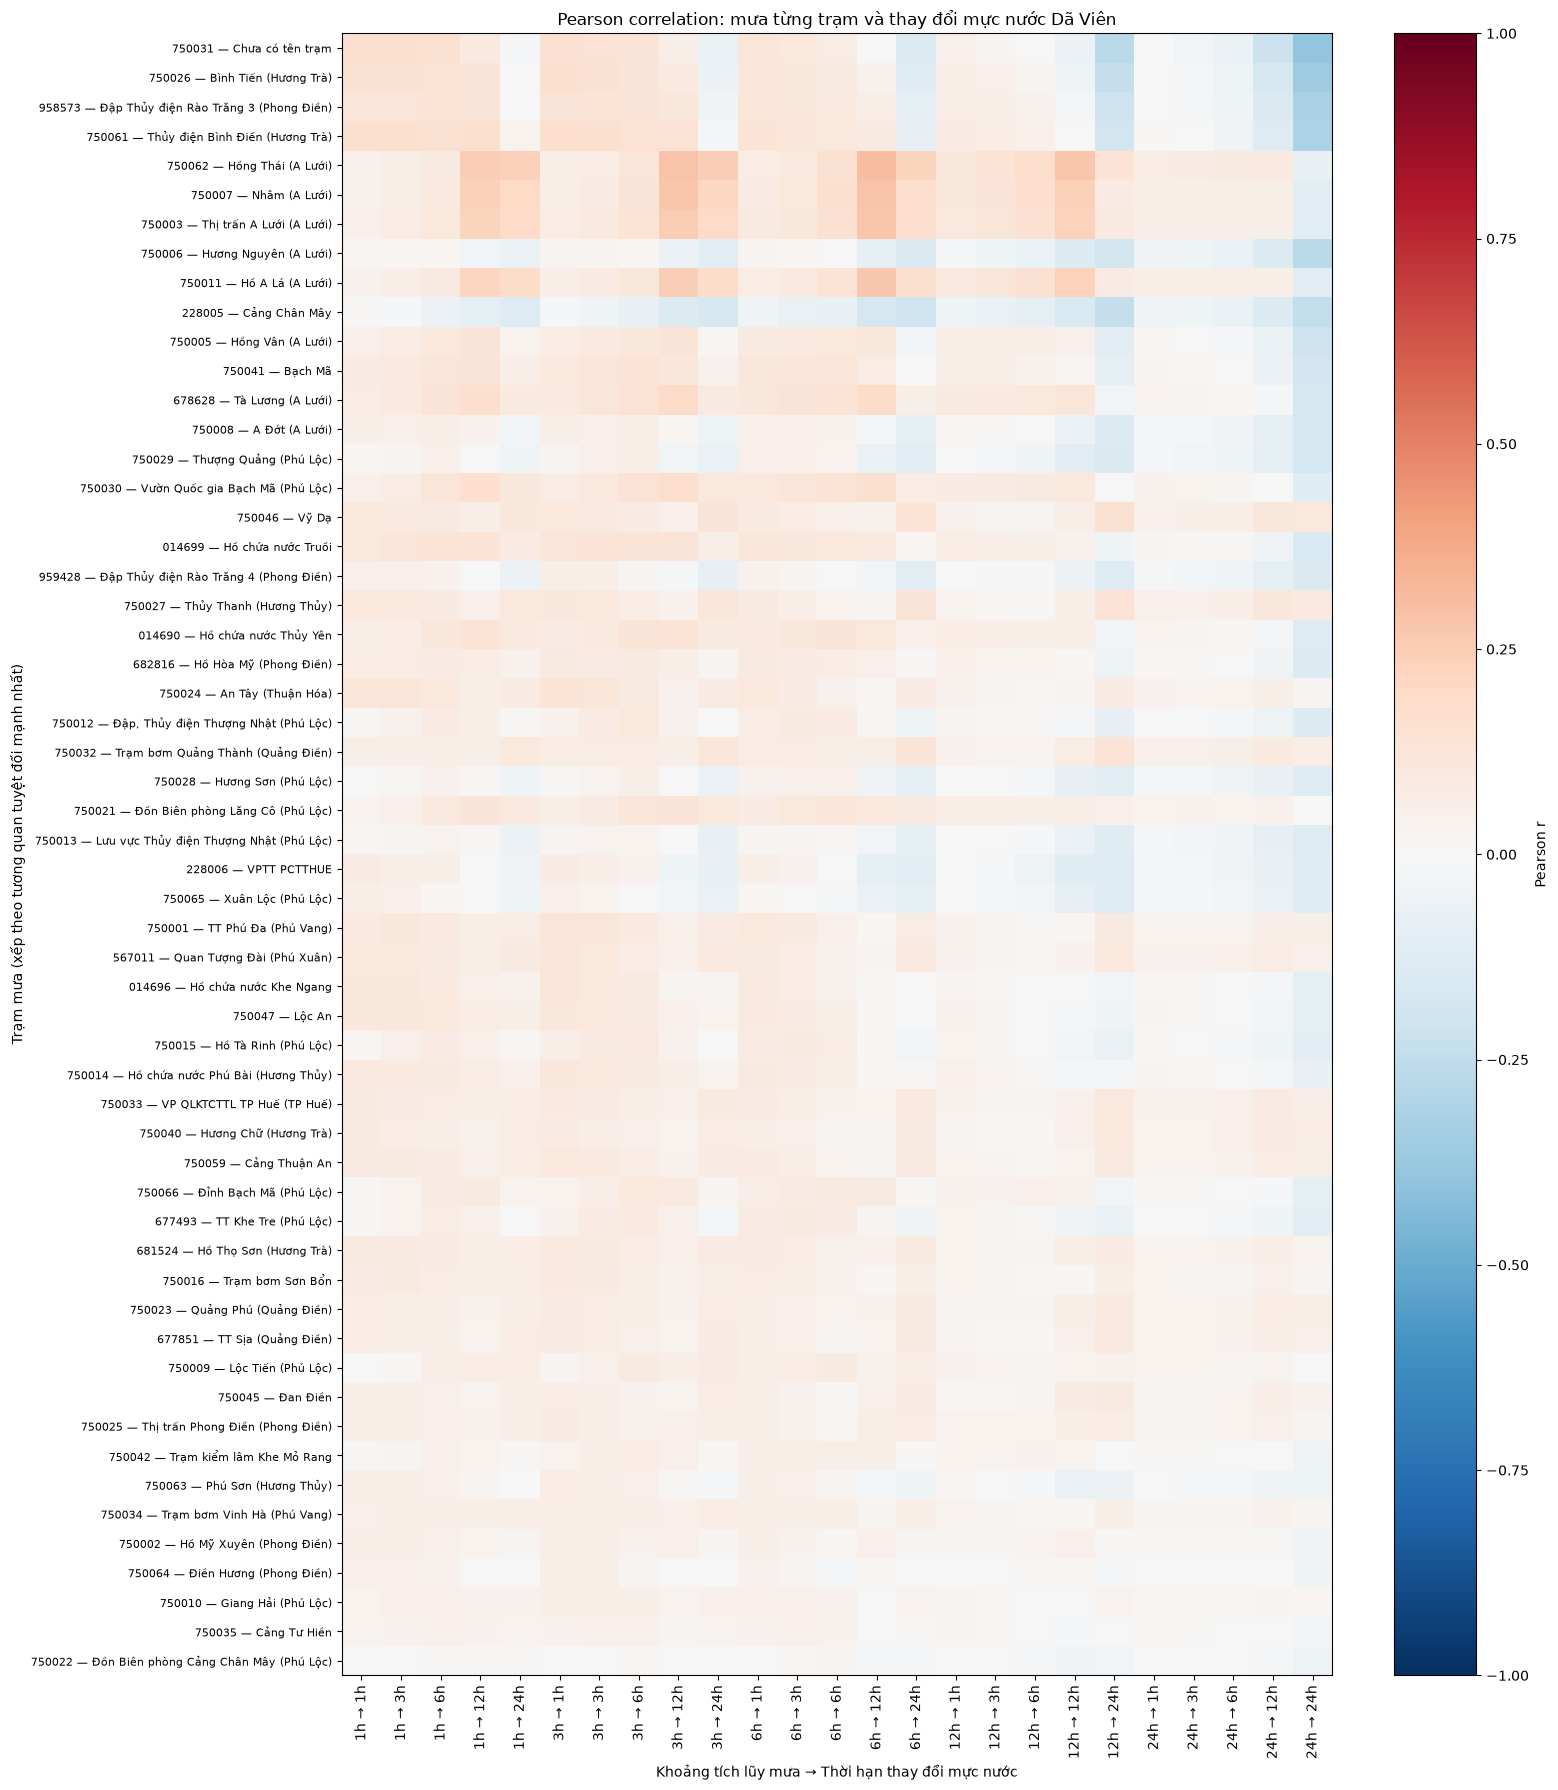

In [43]:
# Mỗi hàng là một trạm; mỗi cột là một cặp cửa sổ mưa → thời hạn dự báo.
station_order = correlation_results["station"].drop_duplicates()
heatmap = correlation_results.pivot(
    index="station", columns=["rainfall_window", "forecast_horizon"], values="correlation"
).reindex(
    index=station_order,
    columns=pd.MultiIndex.from_product([hours, hours]),
)

fig, ax = plt.subplots(figsize=(16, 18))
colormap = plt.get_cmap("RdBu_r").copy()
colormap.set_bad("lightgray")
image = ax.imshow(
    np.ma.masked_invalid(heatmap.to_numpy()),
    cmap=colormap, vmin=-1, vmax=1, aspect="auto",
)
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels([f"{window}h → {horizon}h" for window, horizon in heatmap.columns], rotation=90)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index, fontsize=8)
ax.set_xlabel("Khoảng tích lũy mưa → Thời hạn thay đổi mực nước")
ax.set_ylabel("Trạm mưa (xếp theo tương quan tuyệt đối mạnh nhất)")
ax.set_title("Pearson correlation: mưa từng trạm và thay đổi mực nước Dã Viên")
fig.colorbar(image, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()


## Nhận xét từ phân tích hiện tại

- Đã tính 1.400 tổ hợp từ 56 trạm × 5 cửa sổ mưa × 5 thời hạn. Số cặp dữ liệu hợp lệ nằm trong khoảng 4.327–7.665; đây là các cặp theo giờ và không hoàn toàn độc lập với nhau.
- Tương quan tuyệt đối lớn nhất là **−0,396** tại trạm **750031** (chưa có tên trong bảng thông tin trạm), với mưa tích lũy **24 giờ** và thay đổi mực nước trong **24 giờ tới**, trên **4.327 cặp**. Trạm này có ít dữ liệu hơn phần lớn các trạm khác.
- Một số trạm cũng có tương quan âm nổi bật ở cặp **24 giờ → 24 giờ**: Bình Tiến (**−0,356**), Đập Thủy điện Rào Trăng 3 (**−0,321**) và Thủy điện Bình Điền (**−0,314**). Đây là liên hệ giữa mưa đã xảy ra và mức thay đổi nước sau đó, không chứng minh mưa làm nước giảm.
- Tương quan dương lớn nhất là **0,306** tại **Hồng Thái**, với mưa tích lũy **6 giờ** và thay đổi mực nước trong **12 giờ tới**, trên **7.648 cặp**. Nhâm (**0,288**) và Thị trấn A Lưới (**0,274**) cũng nổi bật ở cùng cặp cửa sổ/thời hạn.
- Trong các kết quả này, chưa có hệ số Pearson nào có độ lớn vượt 0,4. Cửa sổ 6 giờ và horizon 12 giờ thể hiện một liên hệ đáng chú ý ở một số trạm A Lưới, nhưng không có nghĩa thời gian nước truyền về Dã Viên chính xác là 12 giờ.

Các kết quả sử dụng toàn bộ giai đoạn có dữ liệu. Chúng chỉ mô tả tương quan, chưa xác định nguyên nhân hoặc chứng minh trạm nào sẽ giúp mô hình dự báo tốt hơn.


## Top 5 tương quan dương và scatter plot
Mỗi trạm dùng đúng cửa sổ mưa và horizon có Pearson r dương cao nhất trong toàn bộ dữ liệu. Đường đỏ là đường hồi quy tuyến tính đơn giản. Bảng độ nhạy bên dưới giúp xem kết quả thay đổi thế nào khi bỏ một phần rất nhỏ các giá trị cực lớn; không coi các giá trị này là dữ liệu sai.


,station,rainfall_window,forecast_horizon,correlation,sample_count
0,750062 — Hồng Thái (A Lưới),6,12,0.306,7648
1,750007 — Nhâm (A Lưới),6,12,0.288,7654
2,750003 — Thị trấn A Lưới (A Lưới),6,12,0.274,7631
3,750011 — Hồ A Lá (A Lưới),6,12,0.266,7654
4,678628 — Tà Lương (A Lưới),3,12,0.190,7654


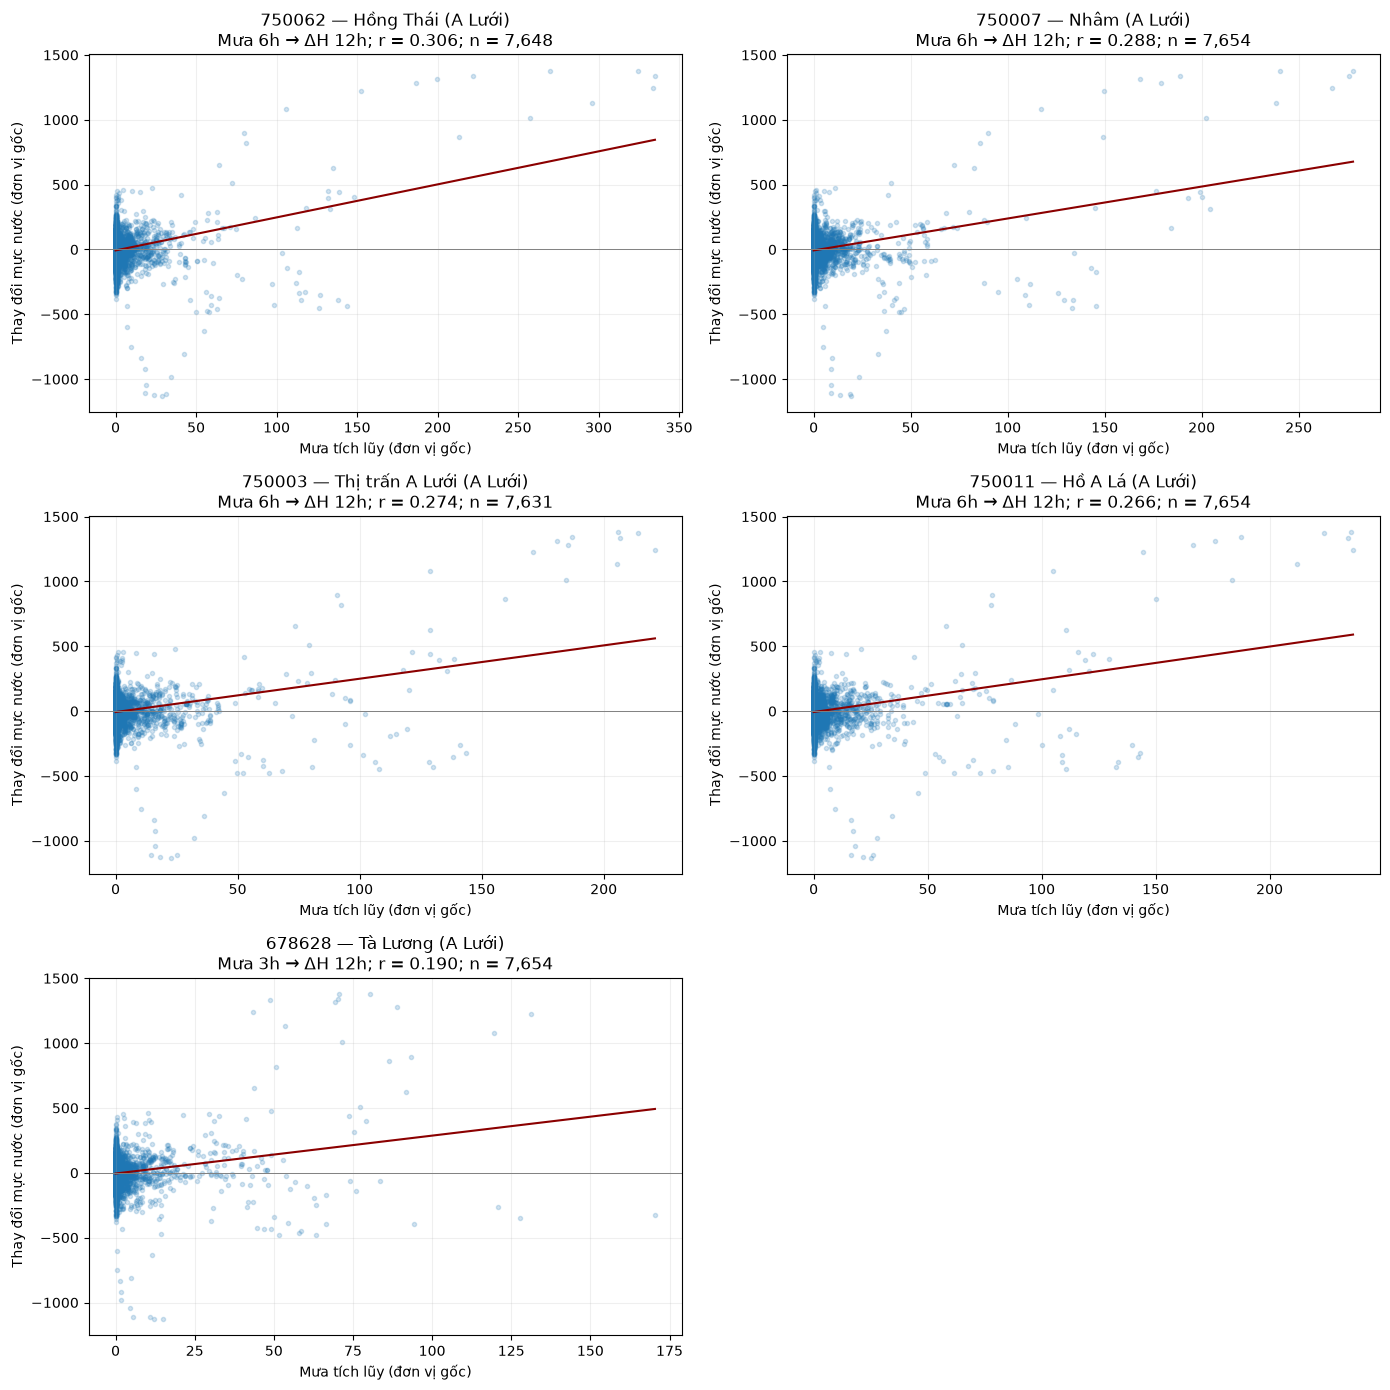

Kiểm tra độ nhạy khi bỏ các giá trị cực lớn; không thay thế kết quả chính:


,station,rainfall_window,forecast_horizon,correlation_all,correlation_without_extremes,sample_count_all,sample_count_without_extremes
0,750062 — Hồng Thái (A Lưới),6,12,0.306,0.031,7648,7535
1,750007 — Nhâm (A Lưới),6,12,0.288,0.017,7654,7528
2,750003 — Thị trấn A Lưới (A Lưới),6,12,0.274,0.010,7631,7516
3,750011 — Hồ A Lá (A Lưới),6,12,0.266,0.015,7654,7537
4,678628 — Tà Lương (A Lưới),3,12,0.190,0.065,7654,7533


In [44]:
# Chạy sau cell rain-water-correlation-compute.
# Chỉ xếp hạng correlation dương; mỗi trạm xuất hiện một lần.
top5_positive = (
    correlation_results[correlation_results["correlation"] > 0]
    .sort_values("correlation", ascending=False)
    .drop_duplicates("station")
    .head(5)
    .reset_index(drop=True)
)
display(top5_positive.round({"correlation": 3}))

# Lưu các cửa sổ đã tính để dùng lại khi tách mùa.
rain_windows = {
    window: rain_hourly.rolling(window, min_periods=window).sum().reindex(water_hourly.index)
    for window in hours
}

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
sensitivity_records = []
for ax, row in zip(axes.flat, top5_positive.itertuples(index=False)):
    station_id = row.station.split(" — ", 1)[0]
    paired = pd.concat([
        rain_windows[row.rainfall_window][station_id].rename("rainfall"),
        water_changes[row.forecast_horizon].rename("delta_water_level"),
    ], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    ax.scatter(paired["rainfall"], paired["delta_water_level"], s=9, alpha=0.2)
    slope, intercept = np.polyfit(paired["rainfall"], paired["delta_water_level"], 1)
    x_line = np.array([paired["rainfall"].min(), paired["rainfall"].max()])
    ax.plot(x_line, slope * x_line + intercept, color="darkred", linewidth=1.5)
    ax.axhline(0, color="gray", linewidth=0.7)
    ax.set_title(
        f"{row.station}\nMưa {row.rainfall_window}h → ΔH {row.forecast_horizon}h; "
        f"r = {row.correlation:.3f}; n = {len(paired):,}"
    )
    ax.set_xlabel("Mưa tích lũy (đơn vị gốc)")
    ax.set_ylabel("Thay đổi mực nước (đơn vị gốc)")
    ax.grid(alpha=0.2)

    # Kiểm tra độ nhạy đơn giản: bỏ các cặp nằm trong 1% giá trị cao nhất
    # của mưa hoặc |delta|. Các giá trị lớn vẫn được giữ trong kết quả chính.
    trimmed = paired[
        (paired["rainfall"] <= paired["rainfall"].quantile(0.99))
        & (paired["delta_water_level"].abs() <= paired["delta_water_level"].abs().quantile(0.99))
    ]
    sensitivity_records.append({
        "station": row.station,
        "rainfall_window": row.rainfall_window,
        "forecast_horizon": row.forecast_horizon,
        "correlation_all": paired["rainfall"].corr(paired["delta_water_level"]),
        "correlation_without_extremes": trimmed["rainfall"].corr(trimmed["delta_water_level"]),
        "sample_count_all": len(paired),
        "sample_count_without_extremes": len(trimmed),
    })
for ax in axes.flat[len(top5_positive):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

outlier_sensitivity = pd.DataFrame(sensitivity_records)
print("Kiểm tra độ nhạy khi bỏ các giá trị cực lớn; không thay thế kết quả chính:")
display(outlier_sensitivity.round(3))


## Tương quan riêng theo mùa
Mùa lũ được quy ước là tháng 9–12; ngoài mùa lũ là tháng 1–8. Mùa được xác định tại thời điểm t. Lượng mưa chỉ dùng cửa sổ kết thúc tại t; delta dùng H(t + horizon) − H(t). Các cặp thiếu dữ liệu được bỏ riêng cho từng tổ hợp.


In [45]:
# Gán mùa theo thời điểm phát dự báo t, dùng giờ Việt Nam.
# Horizon đi qua ranh giới tháng vẫn được gán theo mùa của t.
season_at_t = pd.Series(
    np.where(water_hourly.index.month.isin([9, 10, 11, 12]), "Mùa lũ", "Ngoài mùa lũ"),
    index=water_hourly.index,
    name="season",
)
season_records = []
for window, accumulated_rain in rain_windows.items():
    for station_id in accumulated_rain.columns:
        station = f"{station_id} — {station_names.get(station_id, 'Chưa có tên trạm')}"
        for horizon in hours:
            paired = pd.concat([
                accumulated_rain[station_id].rename("rainfall"),
                water_changes[horizon].rename("delta_water_level"),
                season_at_t,
            ], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
            for season in ["Mùa lũ", "Ngoài mùa lũ"]:
                subset = paired[paired["season"] == season]
                correlation = np.nan
                if len(subset) >= 3 and subset[["rainfall", "delta_water_level"]].nunique().min() > 1:
                    correlation = subset["rainfall"].corr(subset["delta_water_level"], method="pearson")
                season_records.append({
                    "station": station,
                    "rainfall_window": window,
                    "forecast_horizon": horizon,
                    "season": season,
                    "correlation": correlation,
                    "sample_count": len(subset),
                })

season_correlations = pd.DataFrame(season_records).sort_values(
    ["season", "correlation"], ascending=[True, False], na_position="last"
).reset_index(drop=True)

# Top 5 trạm riêng biệt có correlation dương cao nhất trong mỗi mùa.
season_top5 = {}
for season in ["Mùa lũ", "Ngoài mùa lũ"]:
    season_top5[season] = (
        season_correlations[
            (season_correlations["season"] == season)
            & (season_correlations["correlation"] > 0)
        ]
        .sort_values("correlation", ascending=False)
        .drop_duplicates("station")
        .head(5)
    )
    print(f"Top 5 correlation dương — {season}:")
    display(season_top5[season].round({"correlation": 3}))

# So sánh cùng cửa sổ và horizon tốt nhất từ phân tích toàn bộ dữ liệu.
original_combinations = top5_positive[["station", "rainfall_window", "forecast_horizon"]]
season_comparison = season_correlations.merge(
    original_combinations, on=["station", "rainfall_window", "forecast_horizon"], how="inner"
)
print("So sánh top 5 cũ với đúng cửa sổ mưa và horizon ban đầu:")
display(season_comparison.round({"correlation": 3}))

# Cửa sổ/horizon tốt nhất của 5 trạm cũ có thể thay đổi sau khi tách mùa.
best_old_stations_by_season = (
    season_correlations[season_correlations["station"].isin(top5_positive["station"])]
    .sort_values("correlation", ascending=False)
    .drop_duplicates(["station", "season"])
    .sort_values(["station", "season"])
)
print("Tổ hợp có correlation cao nhất trong từng mùa của 5 trạm cũ:")
display(best_old_stations_by_season.round({"correlation": 3}))


Top 5 correlation dương — Mùa lũ:


,station,rainfall_window,forecast_horizon,season,correlation,sample_count
0,750062 — Hồng Thái (A Lưới),6,12,Mùa lũ,0.408,1816
1,750007 — Nhâm (A Lưới),6,12,Mùa lũ,0.385,1822
5,750003 — Thị trấn A Lưới (A Lưới),6,12,Mùa lũ,0.372,1799
6,750011 — Hồ A Lá (A Lưới),6,12,Mùa lũ,0.362,1822
18,750030 — Vườn Quốc gia Bạch Mã (Phú Lộc),3,12,Mùa lũ,0.285,1822


Top 5 correlation dương — Ngoài mùa lũ:


,station,rainfall_window,forecast_horizon,season,correlation,sample_count
1400,958573 — Đập Thủy điện Rào Trăng 3 (Phong Điền),3,3,Ngoài mùa lũ,0.084,5832
1404,959428 — Đập Thủy điện Rào Trăng 4 (Phong Điền),3,3,Ngoài mùa lũ,0.076,5648
1408,678628 — Tà Lương (A Lưới),3,3,Ngoài mùa lũ,0.073,5832
1409,014696 — Hồ chứa nước Khe Ngang,3,3,Ngoài mùa lũ,0.073,5832
1412,750008 — A Đớt (A Lưới),3,6,Ngoài mùa lũ,0.070,5832


So sánh top 5 cũ với đúng cửa sổ mưa và horizon ban đầu:


,station,rainfall_window,forecast_horizon,season,correlation,sample_count
0,750062 — Hồng Thái (A Lưới),6,12,Mùa lũ,0.408,1816
1,750007 — Nhâm (A Lưới),6,12,Mùa lũ,0.385,1822
2,750003 — Thị trấn A Lưới (A Lưới),6,12,Mùa lũ,0.372,1799
3,750011 — Hồ A Lá (A Lưới),6,12,Mùa lũ,0.362,1822
4,678628 — Tà Lương (A Lưới),3,12,Mùa lũ,0.269,1822
5,750003 — Thị trấn A Lưới (A Lưới),6,12,Ngoài mùa lũ,0.022,5832
6,750007 — Nhâm (A Lưới),6,12,Ngoài mùa lũ,0.014,5832
7,750011 — Hồ A Lá (A Lưới),6,12,Ngoài mùa lũ,0.014,5832
8,678628 — Tà Lương (A Lưới),3,12,Ngoài mùa lũ,0.013,5832
9,750062 — Hồng Thái (A Lưới),6,12,Ngoài mùa lũ,0.003,5832


Tổ hợp có correlation cao nhất trong từng mùa của 5 trạm cũ:


,station,rainfall_window,forecast_horizon,season,correlation,sample_count
19,678628 — Tà Lương (A Lưới),3,12,Mùa lũ,0.269,1822
1408,678628 — Tà Lương (A Lưới),3,3,Ngoài mùa lũ,0.073,5832
5,750003 — Thị trấn A Lưới (A Lưới),6,12,Mùa lũ,0.372,1799
1498,750003 — Thị trấn A Lưới (A Lưới),3,3,Ngoài mùa lũ,0.046,5832
1,750007 — Nhâm (A Lưới),6,12,Mùa lũ,0.385,1822
1693,750007 — Nhâm (A Lưới),3,1,Ngoài mùa lũ,0.024,5832
6,750011 — Hồ A Lá (A Lưới),6,12,Mùa lũ,0.362,1822
1653,750011 — Hồ A Lá (A Lưới),3,1,Ngoài mùa lũ,0.028,5832
0,750062 — Hồng Thái (A Lưới),6,12,Mùa lũ,0.408,1816
1546,750062 — Hồng Thái (A Lưới),3,3,Ngoài mùa lũ,0.039,5832


## Nhận xét sau khi xem scatter và tách mùa

### Scatter và độ nhạy với các giá trị cực lớn

Top 5 tương quan dương toàn bộ giai đoạn vẫn là Hồng Thái, Nhâm, Thị trấn A Lưới, Hồ A Lá và Tà Lương. Các scatter plot cho thấy phần lớn điểm tập trung ở vùng mưa nhỏ, trong khi một nhóm nhỏ có mưa hoặc mức thay đổi nước rất lớn.

Khi bỏ các cặp thuộc 1% giá trị mưa cao nhất **hoặc** 1% độ lớn thay đổi mực nước cao nhất (tính riêng cho từng trạm/tổ hợp), Pearson r giảm như sau:

| Trạm | Toàn bộ dữ liệu | Sau khi bỏ các giá trị cực lớn | Số cặp giữ lại / ban đầu |
|---|---:|---:|---:|
| Hồng Thái | 0,306 | 0,031 | 7.535 / 7.648 |
| Nhâm | 0,288 | 0,017 | 7.528 / 7.654 |
| Thị trấn A Lưới | 0,274 | 0,010 | 7.516 / 7.631 |
| Hồ A Lá | 0,266 | 0,015 | 7.537 / 7.654 |
| Tà Lương | 0,190 | 0,065 | 7.533 / 7.654 |

Các hệ số rất nhạy với một phần nhỏ giá trị cực lớn. Đây chỉ là phép kiểm tra độ nhạy; không có nghĩa các điểm lớn là sai hoặc cần loại khỏi dataset.

### So sánh giữa hai mùa

- **Mùa lũ:** Hồng Thái (0,408), Nhâm (0,385), Thị trấn A Lưới (0,372) và Hồ A Lá (0,362) vẫn dẫn đầu, đều ở cửa sổ mưa 6 giờ và horizon 12 giờ. Vườn Quốc gia Bạch Mã đứng thứ năm (0,285), ở cửa sổ 3 giờ và horizon 12 giờ.
- **Ngoài mùa lũ:** top 5 là Đập Thủy điện Rào Trăng 3 (0,084), Đập Thủy điện Rào Trăng 4 (0,076), Tà Lương (0,073), Hồ chứa nước Khe Ngang (0,073) và A Đớt (0,070). Đây là các tên trạm mưa trong bảng thông tin trạm; phân tích vẫn chỉ sử dụng số đo mưa. Bốn trạm đầu nổi bật ở cửa sổ 3 giờ/horizon 3 giờ; A Đớt ở cửa sổ 3 giờ/horizon 6 giờ.
- **Giữ nguyên tổ hợp mưa 6 giờ → thay đổi nước 12 giờ:** Hồng Thái giảm từ 0,408 trong mùa lũ xuống 0,003 ngoài mùa lũ; Nhâm từ 0,385 xuống 0,014; Thị trấn A Lưới từ 0,372 xuống 0,022. Như vậy, ba trạm này còn nổi bật trong mùa lũ nhưng không còn đứng đầu ngoài mùa lũ.

Mỗi nhóm mùa có số cặp khác nhau. Với tổ hợp 6 giờ → 12 giờ, ba trạm trên có khoảng 1.799–1.822 cặp mùa lũ và 5.832 cặp ngoài mùa lũ. Theo phạm vi dữ liệu mực nước hiện có, nhóm mùa lũ gồm một phần tháng 11/2025, tháng 12/2025 và tháng 9/2026; chưa có dữ liệu mực nước tháng 10. Vì vậy, kết quả chưa đại diện cho nhiều mùa lũ độc lập hoặc đầy đủ bốn tháng.

Các bảng mô tả sự thay đổi của tương quan theo mùa. Không suy ra nguyên nhân nhân quả, thời gian truyền nước chính xác hoặc hiệu quả của một mô hình dự báo từ những hệ số này.


## Response mùa lũ: lag 1–24 giờ
Tập trung vào Hồng Thái, Nhâm, Thị trấn A Lưới và Hồ A Lá. So sánh mưa tích lũy 1/3/6 giờ tại t với H(t+h) − H(t), h từ 1 đến 24. Mùa được xác định theo t (tháng 9–12); H là mực nước trung bình của giờ vừa kết thúc. Lag có r cao nhất chỉ là horizon có association mạnh nhất, không phải thời gian truyền nước thực tế.


Tổ hợp có correlation dương cao nhất của mỗi trạm:


,station,rainfall_window,lag_hours,correlation,sample_count
0,750062 — Hồng Thái (A Lưới),6,12,0.408,1816
1,750007 — Nhâm (A Lưới),6,12,0.385,1822
2,750003 — Thị trấn A Lưới (A Lưới),6,13,0.372,1798
3,750011 — Hồ A Lá (A Lưới),6,12,0.362,1822


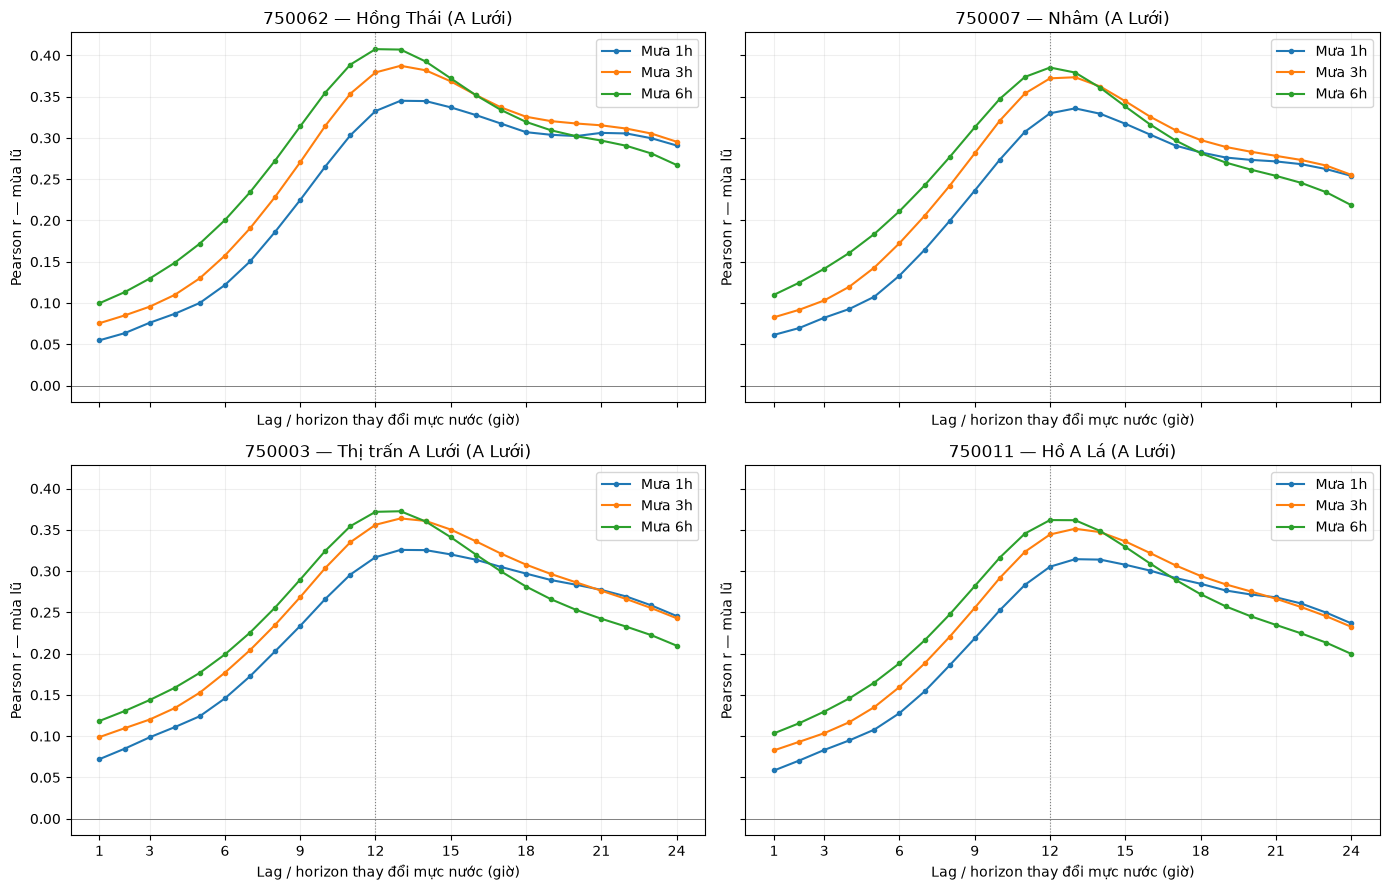

In [46]:
# Chạy sau cell rain-water-correlation-compute để có rain_hourly và water_hourly.
focus_stations = ["750062", "750007", "750003", "750011"]
response_windows = [1, 3, 6]
response_lags = range(1, 25)
flood_at_t = water_hourly.index.month.isin([9, 10, 11, 12])
response_rain = {
    window: rain_hourly[focus_stations].rolling(window, min_periods=window).sum()
    .reindex(water_hourly.index)
    for window in response_windows
}


def response_pairs(station_id, window, lag):
    # Rain chỉ dùng các giờ kết thúc tại hoặc trước t; delta dùng đúng t + lag.
    paired = pd.concat([
        response_rain[window][station_id].rename("rainfall"),
        (water_hourly.shift(-lag) - water_hourly).rename("delta_water_level"),
    ], axis=1).replace([np.inf, -np.inf], np.nan)
    return paired.loc[flood_at_t].dropna()


lag_records = []
for station_id in focus_stations:
    for window in response_windows:
        for lag in response_lags:
            paired = response_pairs(station_id, window, lag)
            correlation = np.nan
            if len(paired) >= 3 and paired.nunique().min() > 1:
                correlation = paired["rainfall"].corr(paired["delta_water_level"])
            lag_records.append({
                "station": f"{station_id} — {station_names.get(station_id, station_id)}",
                "rainfall_window": window,
                "lag_hours": lag,
                "correlation": correlation,
                "sample_count": len(paired),
            })
lag_results = pd.DataFrame(lag_records)
best_lag_per_station = (
    lag_results[lag_results["correlation"] > 0]
    .sort_values("correlation", ascending=False)
    .drop_duplicates("station")
    .reset_index(drop=True)
)
print("Tổ hợp có correlation dương cao nhất của mỗi trạm:")
display(best_lag_per_station.round({"correlation": 3}))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for ax, station_id in zip(axes.flat, focus_stations):
    station = f"{station_id} — {station_names.get(station_id, station_id)}"
    for window in response_windows:
        subset = lag_results[
            (lag_results["station"] == station) & (lag_results["rainfall_window"] == window)
        ]
        ax.plot(subset["lag_hours"], subset["correlation"], marker=".", label=f"Mưa {window}h")
    ax.axhline(0, color="gray", linewidth=0.7)
    ax.axvline(12, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(station)
    ax.set_xlabel("Lag / horizon thay đổi mực nước (giờ)")
    ax.set_ylabel("Pearson r — mùa lũ")
    ax.set_xticks([1, 3, 6, 9, 12, 15, 18, 21, 24])
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()


## Các event mưa đáng kể và phản ứng trong 24 giờ
Gộp các giờ có mưa liên tục hoặc cách nhau tối đa 2 giờ không mưa; không nối qua giờ thiếu. Một event được chọn khi mưa 1h lớn nhất đạt P95 của các giờ có mưa trong mùa lũ và khoảng có số đo Dã Viên, tính riêng cho từng trạm. P95 là quy tắc khám phá minh bạch, không phải ngưỡng cảnh báo lũ.

Event start là đầu giờ mưa đầu tiên, event end là cuối giờ mưa cuối cùng. Tổng mưa bao gồm toàn event, còn max water/change và time-to-max chỉ xét [event_start, event_start + 24h], không tính 24h từ cuối event. Nếu thiếu bất kỳ mốc nước nào trong 25 mốc theo giờ của khoảng này, kết quả response được để NaN. Event bắt đầu trước chuỗi mực nước không được đánh giá. Giá trị tổng mưa toàn event chỉ dùng mô tả, không phải feature dự báo tại event_start.


In [47]:
# Event: các giờ mưa > 0 được gộp nếu cách nhau tối đa 2 giờ không mưa.
# Không nối event qua giờ thiếu dữ liệu. Ngưỡng "đáng kể" là P95 của
# lượng mưa 1h DƯƠNG trong mùa lũ, trên khoảng có số đo mực nước.
# Một event đáng kể phải có ít nhất một giờ đạt ngưỡng này.
dry_gap_hours = 2
threshold_quantile = 0.95
threshold_records = []
event_records = []

for station_id in focus_stations:
    rainfall = rain_hourly[station_id]
    common_rain = rainfall.reindex(water_hourly.index)
    wet_flood_hours = common_rain.loc[
        flood_at_t & water_hourly.notna().to_numpy() & common_rain.gt(0).to_numpy()
    ]
    threshold = wet_flood_hours.quantile(threshold_quantile)
    station = f"{station_id} — {station_names.get(station_id, station_id)}"
    threshold_records.append({
        "station": station,
        "threshold_percentile": 95,
        "threshold_1h_rainfall": threshold,
        "wet_hour_sample_count": len(wet_flood_hours),
        "max_dry_gap_hours": dry_gap_hours,
    })

    # Tìm event trên toàn chuỗi trước khi lọc mùa, tránh cắt đợt mưa ở ranh giới.
    wet_times = rainfall[rainfall > 0].index
    spans = []
    first_wet = previous_wet = None
    for timestamp in wet_times:
        if first_wet is None:
            first_wet = timestamp
        elif (
            timestamp - previous_wet > pd.Timedelta(hours=dry_gap_hours + 1)
            or rainfall.loc[previous_wet:timestamp].isna().any()
        ):
            spans.append((first_wet, previous_wet))
            first_wet = timestamp
        previous_wet = timestamp
    if first_wet is not None:
        spans.append((first_wet, previous_wet))

    for first_wet, last_wet in spans:
        # Nhãn mưa theo giờ là cuối khoảng đo. Start là đầu giờ mưa đầu tiên,
        # nên H(start) nằm trước số đo mưa của giờ đó.
        event_start = first_wet - pd.Timedelta(hours=1)
        event_end = last_wet
        event_rain = rainfall.loc[first_wet:last_wet]
        if event_start.month not in [9, 10, 11, 12]:
            continue
        if not water_hourly.index.min() <= event_start <= water_hourly.index.max():
            continue
        if pd.isna(threshold) or event_rain.max() < threshold:
            continue

        next_24h = water_hourly.reindex(pd.date_range(
            event_start, event_start + pd.Timedelta(hours=24), freq="1h"
        ))
        complete_response = next_24h.notna().all()
        initial_water = next_24h.iloc[0]
        peak_water = next_24h.max() if complete_response else np.nan
        peak_time = next_24h.idxmax() if complete_response else pd.NaT
        event_records.append({
            "station": station,
            "event_start": event_start,
            "event_end": event_end,
            "total_rainfall": event_rain.sum(min_count=1),
            "max_1h_rainfall": event_rain.max(),
            "water_level_at_start": initial_water,
            "max_water_level_next_24h": peak_water,
            "max_water_level_change_next_24h": peak_water - initial_water,
            "time_to_max_water_level_change": (
                (peak_time - event_start).total_seconds() / 3600 if complete_response else np.nan
            ),
            "complete_response": complete_response,
        })

event_thresholds = pd.DataFrame(threshold_records)
rain_events = pd.DataFrame(event_records).sort_values("total_rainfall", ascending=False).reset_index(drop=True)
print("Ngưỡng P95 từ các giờ có mưa, tính riêng cho từng trạm (đơn vị gốc):")
display(event_thresholds.round(3))
print("Các event lớn nhất theo tổng lượng mưa:")
display(rain_events.head(12))
print("Các event có mức tăng nước lớn nhất trong 24h từ lúc bắt đầu:")
display(rain_events.sort_values("max_water_level_change_next_24h", ascending=False).head(12))
print("Số event đáng kể và số event có đủ số đo phản ứng 24h:")
display(rain_events.groupby("station").agg(
    event_count=("event_start", "size"),
    complete_response_count=("complete_response", "sum"),
))


Ngưỡng P95 từ các giờ có mưa, tính riêng cho từng trạm (đơn vị gốc):


,station,threshold_percentile,threshold_1h_rainfall,wet_hour_sample_count,max_dry_gap_hours
0,750062 — Hồng Thái (A Lưới),95,18.40,591,2
1,750007 — Nhâm (A Lưới),95,18.19,608,2
2,750003 — Thị trấn A Lưới (A Lưới),95,19.81,514,2
3,750011 — Hồ A Lá (A Lưới),95,19.47,594,2


Các event lớn nhất theo tổng lượng mưa:


,station,event_start,event_end,total_rainfall,max_1h_rainfall,water_level_at_start,max_water_level_next_24h,max_water_level_change_next_24h,time_to_max_water_level_change,complete_response
0,750062 — Hồng Thái (A Lưới),2025-11-15 04:00:00+07:00,2025-11-19 09:00:00+07:00,847.4,83.0,1009.866667,1040.183333,30.316667,18.0,True
1,750007 — Nhâm (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,767.2,59.8,423.550000,643.416667,219.866667,17.0,True
2,750003 — Thị trấn A Lưới (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,702.6,36.0,423.550000,643.416667,219.866667,17.0,True
3,750011 — Hồ A Lá (A Lưới),2025-11-16 06:00:00+07:00,2025-11-19 21:00:00+07:00,699.6,47.4,830.866667,2664.050000,1833.183333,24.0,True
4,750003 — Thị trấn A Lưới (A Lưới),2025-11-16 05:00:00+07:00,2025-11-19 22:00:00+07:00,698.4,55.0,822.250000,2589.500000,1767.250000,24.0,True
5,750011 — Hồ A Lá (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,688.8,34.4,423.550000,643.416667,219.866667,17.0,True
6,750062 — Hồng Thái (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,668.2,39.6,423.550000,643.416667,219.866667,17.0,True
7,750007 — Nhâm (A Lưới),2025-11-16 06:00:00+07:00,2025-11-19 08:00:00+07:00,662.8,67.6,830.866667,2664.050000,1833.183333,24.0,True
8,750007 — Nhâm (A Lưới),2026-09-20 08:00:00+07:00,2026-09-21 11:00:00+07:00,115.0,22.8,381.616667,555.316667,173.700000,24.0,True
9,750011 — Hồ A Lá (A Lưới),2025-12-20 19:00:00+07:00,2025-12-22 19:00:00+07:00,114.2,19.8,328.416667,536.650000,208.233333,19.0,True


Các event có mức tăng nước lớn nhất trong 24h từ lúc bắt đầu:


,station,event_start,event_end,total_rainfall,max_1h_rainfall,water_level_at_start,max_water_level_next_24h,max_water_level_change_next_24h,time_to_max_water_level_change,complete_response
3,750011 — Hồ A Lá (A Lưới),2025-11-16 06:00:00+07:00,2025-11-19 21:00:00+07:00,699.6,47.4,830.866667,2664.050000,1833.183333,24.0,True
7,750007 — Nhâm (A Lưới),2025-11-16 06:00:00+07:00,2025-11-19 08:00:00+07:00,662.8,67.6,830.866667,2664.050000,1833.183333,24.0,True
4,750003 — Thị trấn A Lưới (A Lưới),2025-11-16 05:00:00+07:00,2025-11-19 22:00:00+07:00,698.4,55.0,822.250000,2589.500000,1767.250000,24.0,True
2,750003 — Thị trấn A Lưới (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,702.6,36.0,423.550000,643.416667,219.866667,17.0,True
5,750011 — Hồ A Lá (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,688.8,34.4,423.550000,643.416667,219.866667,17.0,True
1,750007 — Nhâm (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,767.2,59.8,423.550000,643.416667,219.866667,17.0,True
6,750062 — Hồng Thái (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,668.2,39.6,423.550000,643.416667,219.866667,17.0,True
9,750011 — Hồ A Lá (A Lưới),2025-12-20 19:00:00+07:00,2025-12-22 19:00:00+07:00,114.2,19.8,328.416667,536.650000,208.233333,19.0,True
8,750007 — Nhâm (A Lưới),2026-09-20 08:00:00+07:00,2026-09-21 11:00:00+07:00,115.0,22.8,381.616667,555.316667,173.700000,24.0,True
16,750062 — Hồng Thái (A Lưới),2026-09-04 17:00:00+07:00,2026-09-04 18:00:00+07:00,25.0,25.0,219.150000,390.950000,171.800000,7.0,True


Số event đáng kể và số event có đủ số đo phản ứng 24h:


,event_count,complete_response_count
station,,
750003 — Thị trấn A Lưới (A Lưới),2,2
750007 — Nhâm (A Lưới),6,5
750011 — Hồ A Lá (A Lưới),4,3
750062 — Hồng Thái (A Lưới),5,4


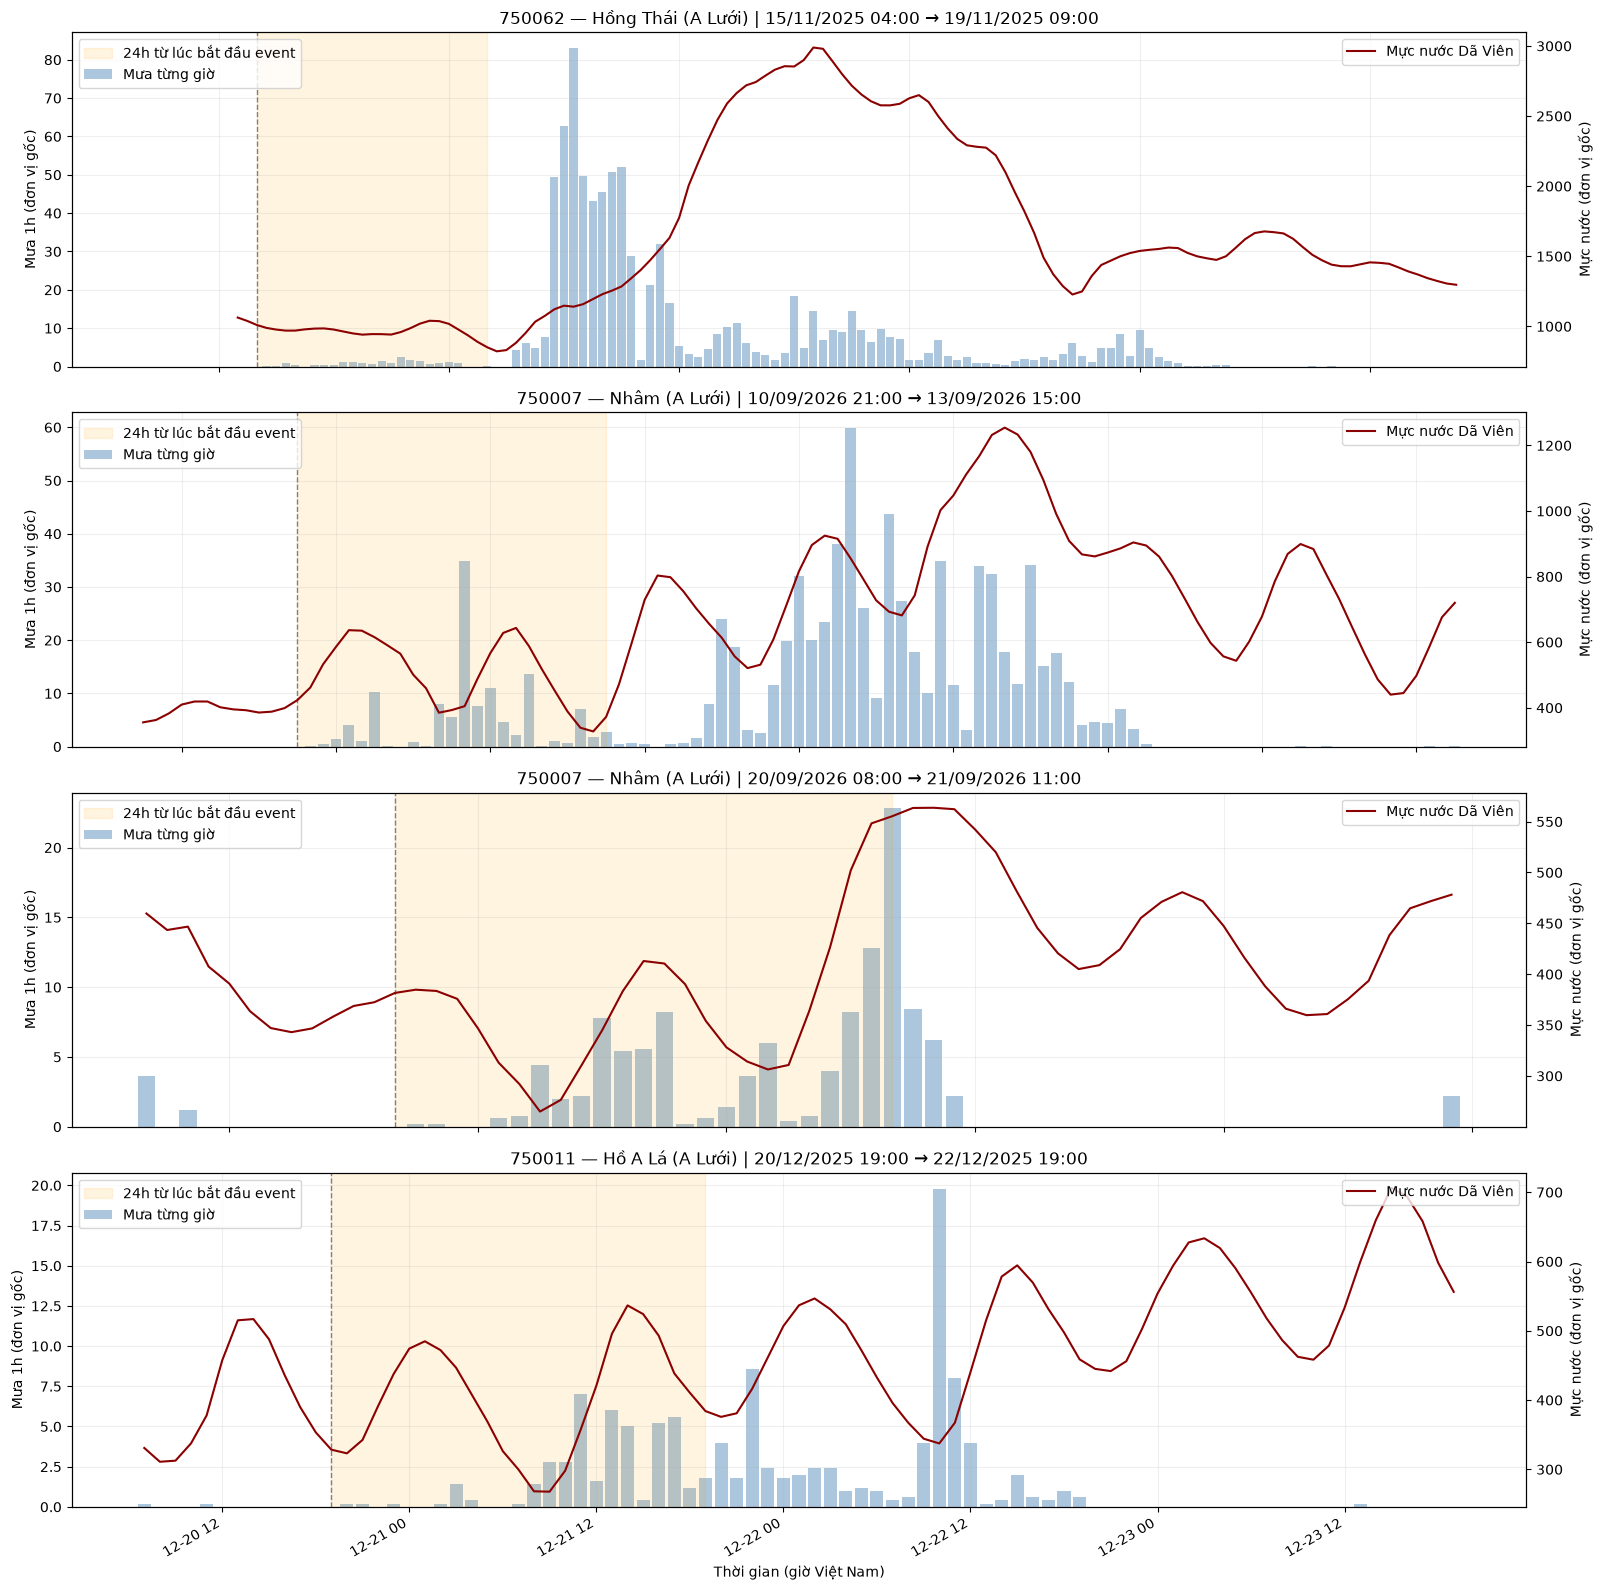

In [48]:
# Chọn tối đa 3 event nhiều mưa nhất có đủ số đo nước, ở các khoảng khác nhau.
# Tránh vẽ lặp cùng một đợt mưa ở nhiều trạm.
plot_events = []
for event in rain_events[rain_events["complete_response"]].itertuples(index=False):
    overlaps = any(
        event.event_start <= previous.event_end + pd.Timedelta(hours=24)
        and event.event_end >= previous.event_start - pd.Timedelta(hours=24)
        for previous in plot_events
    )
    if not overlaps:
        plot_events.append(event)
    if len(plot_events) == 4:
        break

fig, axes = plt.subplots(len(plot_events), 1, figsize=(16, 4 * len(plot_events)), squeeze=False)
for ax, event in zip(axes.flat, plot_events):
    station_id = event.station.split(" — ", 1)[0]
    left = event.event_start - pd.Timedelta(hours=12)
    right = event.event_end + pd.Timedelta(hours=24)
    rain_segment = rain_hourly[station_id].loc[left:right]
    water_segment = water_hourly.loc[left:right]
    water_ax = ax.twinx()
    ax.bar(rain_segment.index, rain_segment.values, width=0.035, alpha=0.45,
           color="steelblue", label="Mưa từng giờ")
    water_ax.plot(water_segment.index, water_segment.values,
                  color="darkred", label="Mực nước Dã Viên")
    ax.axvspan(event.event_start, event.event_start + pd.Timedelta(hours=24),
               color="orange", alpha=0.12, label="24h từ lúc bắt đầu event")
    ax.axvline(event.event_start, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{event.station} | {event.event_start:%d/%m/%Y %H:%M} "
                 f"→ {event.event_end:%d/%m/%Y %H:%M}")
    ax.set_ylabel("Mưa 1h (đơn vị gốc)")
    water_ax.set_ylabel("Mực nước (đơn vị gốc)")
    ax.set_xlabel("Thời gian (giờ Việt Nam)")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left")
    water_ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [49]:
# Kiểm tra 6h rain → delta water 12h khi bỏ từng event đáng kể,
# rồi bỏ đồng thời 3 event có tổng mưa lớn nhất của mỗi trạm.
# Các event có thể là cùng một đợt thời tiết tại các trạm khác nhau.
# Bỏ mọi cặp mà khoảng [t - 6h, t + 12h] giao với event và 24h sau event;
# như vậy không giữ các cửa sổ vẫn chứa mưa/phản ứng của event đang bỏ.
event_sensitivity_records = []
for station_id in focus_stations:
    station = f"{station_id} — {station_names.get(station_id, station_id)}"
    paired = response_pairs(station_id, 6, 12)
    station_events = rain_events[
        (rain_events["station"] == station) & rain_events["complete_response"]
    ].sort_values("total_rainfall", ascending=False)
    cases = [("Toàn bộ mùa lũ", station_events.iloc[:0])]
    for index in range(len(station_events)):
        event = station_events.iloc[index]
        cases.append((f"Bỏ event {event['event_start']:%d/%m/%Y %H:%M}",
                      station_events.iloc[index:index + 1]))
    biggest_rain_events = station_events.head(3)
    cases.append((f"Bỏ {len(biggest_rain_events)} event có tổng mưa lớn nhất", biggest_rain_events))
    for case, excluded_events in cases:
        keep = np.ones(len(paired), dtype=bool)
        for event in excluded_events.itertuples(index=False):
            overlap = (
                (paired.index + pd.Timedelta(hours=12) >= event.event_start)
                & (paired.index - pd.Timedelta(hours=6) <= event.event_end + pd.Timedelta(hours=24))
            )
            keep &= ~overlap
        remaining = paired.loc[keep]
        event_sensitivity_records.append({
            "station": station,
            "case": case,
            "correlation": remaining["rainfall"].corr(remaining["delta_water_level"]),
            "sample_count": len(remaining),
            "removed_sample_count": len(paired) - len(remaining),
        })
event_sensitivity = pd.DataFrame(event_sensitivity_records)
print("Độ nhạy của correlation 6h → 12h khi bỏ các event:")
display(event_sensitivity.round({"correlation": 3}))
print("Thời điểm đạt mức tăng nước lớn nhất, trong các event có mức tăng > 0:")
positive_events = rain_events[rain_events["max_water_level_change_next_24h"] > 0]
display(positive_events.groupby("station")["time_to_max_water_level_change"].agg(
    event_count="size", median_hours="median", min_hours="min", max_hours="max"
))


Độ nhạy của correlation 6h → 12h khi bỏ các event:


,station,case,correlation,sample_count,removed_sample_count
0,750062 — Hồng Thái (A Lưới),Toàn bộ mùa lũ,0.408,1816,0
1,750062 — Hồng Thái (A Lưới),Bỏ event 15/11/2025 04:00,0.032,1682,134
2,750062 — Hồng Thái (A Lưới),Bỏ event 10/09/2026 21:00,0.490,1707,109
3,750062 — Hồng Thái (A Lưới),Bỏ event 19/09/2026 12:00,0.408,1763,53
4,750062 — Hồng Thái (A Lưới),Bỏ event 04/09/2026 17:00,0.410,1772,44
5,750062 — Hồng Thái (A Lưới),Bỏ 3 event có tổng mưa lớn nhất,0.035,1520,296
6,750007 — Nhâm (A Lưới),Toàn bộ mùa lũ,0.385,1822,0
7,750007 — Nhâm (A Lưới),Bỏ event 10/09/2026 21:00,0.502,1713,109
8,750007 — Nhâm (A Lưới),Bỏ event 16/11/2025 06:00,0.061,1705,117
9,750007 — Nhâm (A Lưới),Bỏ event 20/09/2026 08:00,0.392,1752,70


Thời điểm đạt mức tăng nước lớn nhất, trong các event có mức tăng > 0:


,event_count,median_hours,min_hours,max_hours
station,,,,
750003 — Thị trấn A Lưới (A Lưới),2,20.5,17.0,24.0
750007 — Nhâm (A Lưới),5,17.0,7.0,24.0
750011 — Hồ A Lá (A Lưới),3,19.0,17.0,24.0
750062 — Hồng Thái (A Lưới),4,12.0,7.0,18.0


## Kết quả lag chi tiết và phân tích event

### 1. Lag có association dương mạnh nhất

| Trạm | Cửa sổ mưa | Lag tốt nhất | Pearson r | Số cặp |
|---|---:|---:|---:|---:|
| Hồng Thái | 6 giờ | 12 giờ | 0,408 | 1.816 |
| Nhâm | 6 giờ | 12 giờ | 0,385 | 1.822 |
| Thị trấn A Lưới | 6 giờ | 13 giờ | 0,372 | 1.798 |
| Hồ A Lá | 6 giờ | 12 giờ | 0,362 | 1.822 |

Pattern mưa 6 giờ → thay đổi nước khoảng 12 giờ vẫn xuất hiện. Với Thị trấn A Lưới, r ở 13 giờ là 0,37249, rất gần r ở 12 giờ là 0,37177. Chênh lệch nhỏ này chưa đủ để coi 13 giờ là một thời gian phản ứng cố định. Các lag mô tả association với mức tăng/giảm H(t+h) − H(t), không đo thời gian truyền nước thực tế.

### 2. Ngưỡng và số event

Ngưỡng được chọn là **P95 của lượng mưa 1 giờ trong các giờ có mưa của mùa lũ**, trên khoảng có số đo Dã Viên. Không tính các giờ mưa bằng 0 vào phân bố này. Các giờ mưa được gộp khi chỉ cách nhau tối đa 2 giờ không mưa và không có giờ thiếu ở giữa. Khoảng cách 2 giờ là quy ước gộp event trong phân tích, không phải tham số vật lý đã được hiệu chỉnh.

| Trạm | Ngưỡng mưa 1h (đơn vị gốc) | Event đáng kể | Có đủ số đo nước trong 24h |
|---|---:|---:|---:|
| Hồng Thái | 18,40 | 5 | 4 |
| Nhâm | 18,19 | 6 | 5 |
| Thị trấn A Lưới | 19,81 | 2 | 2 |
| Hồ A Lá | 19,47 | 4 | 3 |

Các event của nhiều trạm có thể là cùng một đợt thời tiết, nên không cộng chúng thành số đợt độc lập. Ngưỡng chỉ dùng chọn đợt mưa đáng kể để khám phá, không dùng xác định có lũ.

### 3. Correlation có nhạy với một đợt lớn không?

Giữ nguyên tổ hợp mưa 6h → thay đổi nước 12h và bỏ các cặp có cửa sổ giao với event tháng 11/2025 hoặc 24h sau event:

| Trạm | Toàn bộ mùa lũ | Sau khi bỏ event tháng 11 | Số cặp bị bỏ |
|---|---:|---:|---:|
| Hồng Thái | 0,408 | 0,032 | 134 / 1.816 |
| Nhâm | 0,385 | 0,061 | 117 / 1.822 |
| Thị trấn A Lưới | 0,372 | 0,018 | 132 / 1.799 |
| Hồ A Lá | 0,362 | 0,021 | 130 / 1.822 |

Event tương ứng bắt đầu ngày 15/11/2025 tại Hồng Thái và ngày 16/11/2025 tại ba trạm còn lại; chúng cùng bao phủ đợt tăng nước lớn giữa tháng 11. Correlation giảm mạnh sau khi bỏ các khoảng này, cho thấy association hiện tại phụ thuộc nhiều vào đợt lớn đó. Ngược lại, bỏ event 10–13/9/2026 làm r tăng lên khoảng 0,475–0,502. Vì vậy, quan hệ quan sát được chưa ổn định giữa các đợt. Đây không phải kết luận nguyên nhân hoặc bằng chứng các event lớn là dữ liệu sai.

### 4. Đỉnh trong 24 giờ đầu của event

Với những event có mức tăng nước > 0 và đủ dữ liệu, thời điểm đạt mức tăng lớn nhất trong 24h đầu nằm trong khoảng **7–24 giờ**. Trung vị lần lượt là Hồng Thái 12 giờ (4 event), Nhâm 17 giờ (5 event), Thị trấn A Lưới 20,5 giờ (2 event) và Hồ A Lá 19 giờ (3 event).

Số event còn ít. Khi kết quả là 24 giờ, đỉnh có thể nằm sau giới hạn theo dõi; không được diễn giải là đỉnh thực sự xảy ra đúng 24 giờ. Event Hồng Thái tháng 11 bắt đầu từ mưa nhỏ ngày 15/11, nhưng mưa mạnh và đỉnh nước xảy ra sau 24h đầu, như thấy trên biểu đồ. Vì vậy, thời gian tính từ đầu event và lag tương quan 12–13h là hai cách đo khác nhau.

Chưa đủ bằng chứng để kết luận nước thường đạt đỉnh sau một số giờ cố định. Kết luận phù hợp hiện tại là: association mạnh nhất nằm quanh 12–13h với mưa tích lũy 6h, nhưng rất nhạy với đợt tháng 11/2025. Phạm vi mùa lũ vẫn chỉ gồm một phần tháng 11/2025, tháng 12/2025 và tháng 9/2026, chưa có mực nước tháng 10.


## Phản ứng mực nước tính từ khi mưa trở nên đáng kể

Giữ nguyên các event đáng kể đã xác định ở phần trước (`rain_events`), gồm cách gộp giờ mưa và mốc bắt đầu/kết thúc. Phần này tìm **trigger đầu tiên trong từng event** khi mưa tích lũy 6 giờ vượt P95 của trạm đó. Ngưỡng được tính từ tất cả giá trị 6h hợp lệ trong mùa lũ trên khoảng có số đo nước, **bao gồm giá trị 0**. Đây là ngưỡng khác với P95 mưa 1h dương dùng để chọn event ở phần cũ.

Mưa 6h tại t chỉ gồm 6 giờ kết thúc tại hoặc trước t. Tổng mưa sau trigger dùng 24 giờ trong `(t, t+24h]`. Cửa sổ nước gồm 49 số đo giờ từ t đến t+48h; thiếu bất kỳ số đo nào thì không tính peak và thời gian phản ứng. Không nội suy hay thay dữ liệu thiếu bằng 0. Các giá trị mưa/nước giữ đơn vị gốc; thời gian là giờ Việt Nam.


In [50]:
# Chạy sau rain-event-compute. Không thay đổi rain_events hay dữ liệu gốc.
trigger_rain_6h = rain_hourly[focus_stations].rolling(6, min_periods=6).sum()
trigger_threshold_records = []
trigger_event_records = []

for station_id in focus_stations:
    station = f"{station_id} — {station_names.get(station_id, station_id)}"
    rain_6h = trigger_rain_6h[station_id]
    aligned_rain = rain_6h.reindex(water_hourly.index)
    threshold_data = aligned_rain.loc[
        flood_at_t & water_hourly.notna().to_numpy()
    ].replace([np.inf, -np.inf], np.nan).dropna()
    threshold = threshold_data.quantile(0.95)
    trigger_threshold_records.append({
        "station": station,
        "percentile": 95,
        "threshold_rain_6h": threshold,
        "sample_count": len(threshold_data),
    })

    for event in rain_events.loc[rain_events["station"].eq(station)].itertuples():
        event_rain_6h = rain_6h.loc[
            event.event_start + pd.Timedelta(hours=1):event.event_end
        ]
        crossings = event_rain_6h[event_rain_6h > threshold]
        if crossings.empty:
            continue
        trigger_time = crossings.index[0]
        response = water_hourly.reindex(pd.date_range(
            trigger_time, trigger_time + pd.Timedelta(hours=48), freq="1h"
        )).replace([np.inf, -np.inf], np.nan)
        complete = bool(response.notna().all())
        initial_water = response.iloc[0]
        peak_water = response.max() if complete else np.nan
        peak_time = response.idxmax() if complete else pd.NaT
        peak_delay = (peak_time - trigger_time).total_seconds() / 3600 if complete else np.nan
        rain_after = rain_hourly[station_id].reindex(pd.date_range(
            trigger_time + pd.Timedelta(hours=1),
            trigger_time + pd.Timedelta(hours=24), freq="1h"
        ))
        trigger_event_records.append({
            "station": station,
            "event_start": event.event_start,
            "event_end": event.event_end,
            "trigger_time": trigger_time,
            "rain_6h_at_trigger": crossings.iloc[0],
            "total_rainfall_after_trigger_24h": rain_after.sum(min_count=24),
            "water_level_at_trigger": initial_water,
            "max_water_level_next_48h": peak_water,
            "max_water_level_change_next_48h": peak_water - initial_water,
            "time_to_max_water_level_change": peak_delay,
            "complete_response": complete,
            "peak_at_window_end": bool(complete and peak_delay == 48),
        })

trigger_thresholds = pd.DataFrame(trigger_threshold_records)
trigger_events = pd.DataFrame(trigger_event_records).sort_values(
    "max_water_level_change_next_48h", ascending=False
).reset_index(drop=True)
trigger_counts = rain_events.groupby("station").size().rename("candidate_events").to_frame()
trigger_counts = trigger_counts.join(trigger_events.groupby("station").agg(
    valid_triggers=("trigger_time", "size"),
    complete_responses=("complete_response", "sum"),
)).fillna(0).astype(int)
trigger_response_times = trigger_events.loc[trigger_events["complete_response"]].groupby("station").agg(
    sample_count=("time_to_max_water_level_change", "size"),
    median_hours=("time_to_max_water_level_change", "median"),
    min_hours=("time_to_max_water_level_change", "min"),
    max_hours=("time_to_max_water_level_change", "max"),
    peaks_at_48h=("peak_at_window_end", "sum"),
)
print("Ngưỡng P95 mưa 6h (đơn vị gốc; có tính các giá trị 0):")
display(trigger_thresholds.round({"threshold_rain_6h": 2}))
print("Số event cũ, event có trigger và event đủ dữ liệu nước 48h:")
display(trigger_counts)
print("Tất cả event có trigger, xếp theo mức tăng nước trong 48h:")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(trigger_events)
print("Thời gian đến peak trong cửa sổ 48h, chỉ tính event đủ dữ liệu:")
display(trigger_response_times)
print("Event đạt peak tại cuối cửa sổ: peak thật có thể nằm sau 48h.")
display(trigger_events.loc[trigger_events["peak_at_window_end"], [
    "station", "trigger_time", "time_to_max_water_level_change"
]])


Ngưỡng P95 mưa 6h (đơn vị gốc; có tính các giá trị 0):


,station,percentile,threshold_rain_6h,sample_count
0,750062 — Hồng Thái (A Lưới),95,34.99,1828
1,750007 — Nhâm (A Lưới),95,34.08,1834
2,750003 — Thị trấn A Lưới (A Lưới),95,28.80,1811
3,750011 — Hồ A Lá (A Lưới),95,32.49,1834


Số event cũ, event có trigger và event đủ dữ liệu nước 48h:


,candidate_events,valid_triggers,complete_responses
station,,,
750003 — Thị trấn A Lưới (A Lưới),2,2,2
750007 — Nhâm (A Lưới),6,5,4
750011 — Hồ A Lá (A Lưới),4,4,3
750062 — Hồng Thái (A Lưới),5,3,2


Tất cả event có trigger, xếp theo mức tăng nước trong 48h:


,station,event_start,event_end,trigger_time,rain_6h_at_trigger,total_rainfall_after_trigger_24h,water_level_at_trigger,max_water_level_next_48h,max_water_level_change_next_48h,time_to_max_water_level_change,complete_response,peak_at_window_end
0,750062 — Hồng Thái (A Lưới),2025-11-15 04:00:00+07:00,2025-11-19 09:00:00+07:00,2025-11-16 11:00:00+07:00,72.0,551.4,1121.916667,2988.916667,1867.000000,27.0,True,False
1,750003 — Thị trấn A Lưới (A Lưới),2025-11-16 05:00:00+07:00,2025-11-19 22:00:00+07:00,2025-11-16 11:00:00+07:00,79.2,437.4,1121.916667,2988.916667,1867.000000,27.0,True,False
2,750007 — Nhâm (A Lưới),2025-11-16 06:00:00+07:00,2025-11-19 08:00:00+07:00,2025-11-16 11:00:00+07:00,39.8,503.4,1121.916667,2988.916667,1867.000000,27.0,True,False
3,750011 — Hồ A Lá (A Lưới),2025-11-16 06:00:00+07:00,2025-11-19 21:00:00+07:00,2025-11-16 11:00:00+07:00,65.0,436.4,1121.916667,2988.916667,1867.000000,27.0,True,False
4,750062 — Hồng Thái (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,2026-09-11 10:00:00+07:00,54.6,111.6,404.866667,1254.083333,849.216667,42.0,True,False
5,750007 — Nhâm (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,2026-09-11 10:00:00+07:00,49.4,124.6,404.866667,1254.083333,849.216667,42.0,True,False
6,750003 — Thị trấn A Lưới (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,2026-09-11 10:00:00+07:00,49.0,119.2,404.866667,1254.083333,849.216667,42.0,True,False
7,750011 — Hồ A Lá (A Lưới),2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,2026-09-11 10:00:00+07:00,54.6,127.2,404.866667,1254.083333,849.216667,42.0,True,False
8,750011 — Hồ A Lá (A Lưới),2025-12-20 19:00:00+07:00,2025-12-22 19:00:00+07:00,2025-12-22 11:00:00+07:00,33.8,9.2,367.333333,706.300000,338.966667,28.0,True,False
9,750007 — Nhâm (A Lưới),2026-09-19 12:00:00+07:00,2026-09-19 22:00:00+07:00,2026-09-19 19:00:00+07:00,39.6,28.4,461.933333,563.633333,101.700000,39.0,True,False


Thời gian đến peak trong cửa sổ 48h, chỉ tính event đủ dữ liệu:


,sample_count,median_hours,min_hours,max_hours,peaks_at_48h
station,,,,,
750003 — Thị trấn A Lưới (A Lưới),2,34.5,27.0,42.0,0
750007 — Nhâm (A Lưới),4,33.0,2.0,42.0,0
750011 — Hồ A Lá (A Lưới),3,28.0,27.0,42.0,0
750062 — Hồng Thái (A Lưới),2,34.5,27.0,42.0,0


Event đạt peak tại cuối cửa sổ: peak thật có thể nằm sau 48h.


,station,trigger_time,time_to_max_water_level_change


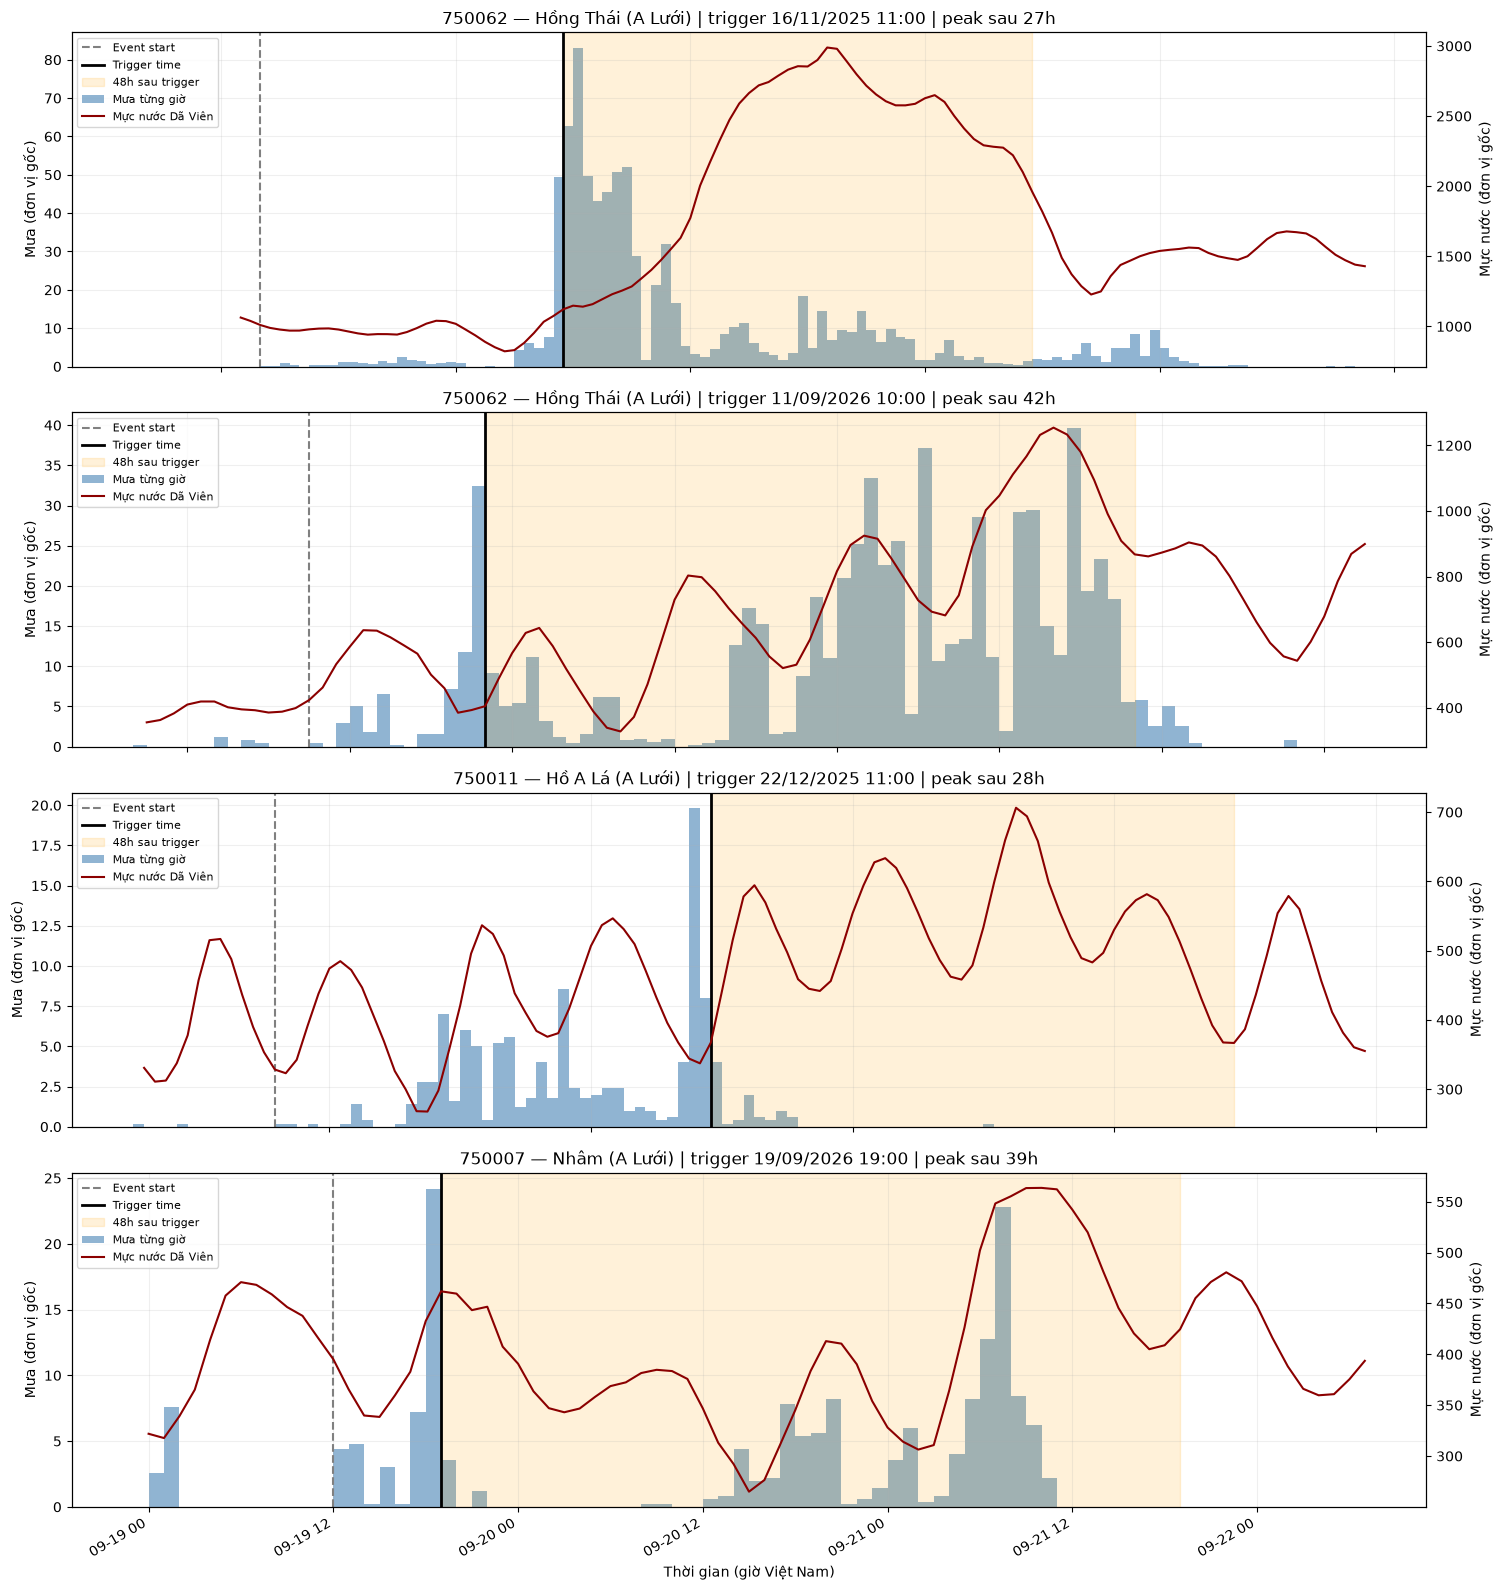

In [51]:
# Chọn tối đa 3 event có mức tăng nước lớn nhất, tránh lặp cùng đợt giữa các trạm.
selected_trigger_events = []
for event in trigger_events.loc[trigger_events["complete_response"]].itertuples():
    if any(abs(event.trigger_time - other.trigger_time) < pd.Timedelta(hours=48)
           for other in selected_trigger_events):
        continue
    selected_trigger_events.append(event)
    if len(selected_trigger_events) == 4:
        break

if selected_trigger_events:
    fig, axes = plt.subplots(len(selected_trigger_events), 1,
                             figsize=(15, 4 * len(selected_trigger_events)), squeeze=False)
    for ax, event in zip(axes.flat, selected_trigger_events):
        station_id = event.station.split(" — ")[0]
        left = event.event_start - pd.Timedelta(hours=12)
        right = max(event.event_end, event.trigger_time + pd.Timedelta(hours=48)) + pd.Timedelta(hours=12)
        rain = rain_hourly[station_id].loc[left:right]
        water = water_hourly.loc[left:right]
        # NaN để trống, không vẽ như giờ không mưa; cột phủ giờ kết thúc tại nhãn t.
        ax.bar(rain.index - pd.Timedelta(hours=1), rain, width=1/24,
               align="edge", color="steelblue", alpha=0.6, label="Mưa từng giờ")
        water_ax = ax.twinx()
        water_ax.plot(water.index, water, color="darkred", label="Mực nước Dã Viên")
        ax.axvline(event.event_start, color="gray", linestyle="--", label="Event start")
        ax.axvline(event.trigger_time, color="black", linewidth=2, label="Trigger time")
        ax.axvspan(event.trigger_time, event.trigger_time + pd.Timedelta(hours=48),
                   color="orange", alpha=0.15, label="48h sau trigger")
        ax.set_title(f"{event.station} | trigger {event.trigger_time:%d/%m/%Y %H:%M} | peak sau {event.time_to_max_water_level_change:g}h")
        ax.set_ylabel("Mưa (đơn vị gốc)")
        water_ax.set_ylabel("Mực nước (đơn vị gốc)")
        ax.set_xlabel("Thời gian (giờ Việt Nam)")
        ax.grid(alpha=0.2)
        handles, labels = ax.get_legend_handles_labels()
        water_handles, water_labels = water_ax.get_legend_handles_labels()
        ax.legend(handles + water_handles, labels + water_labels, fontsize=8, loc="upper left")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


In [3]:
# Hai cách khác nhau cả mốc bắt đầu và độ dài cửa sổ: 24h cũ so với 48h mới.
trigger_comparison = trigger_events.merge(rain_events[[
    "station", "event_start", "event_end", "time_to_max_water_level_change",
    "max_water_level_change_next_24h",
]].rename(columns={"time_to_max_water_level_change": "old_peak_delay_24h"}),
    on=["station", "event_start", "event_end"], how="left", validate="one_to_one")
trigger_comparison["trigger_delay_from_start_hours"] = (
    trigger_comparison["trigger_time"] - trigger_comparison["event_start"]
).dt.total_seconds() / 3600
print("So sánh mốc cũ và mốc trigger; không quy toàn bộ khác biệt cho việc đổi mốc:")
with pd.option_context("display.max_rows", None):
    display(trigger_comparison[[
        "station", "event_start", "trigger_time", "trigger_delay_from_start_hours",
        "old_peak_delay_24h", "time_to_max_water_level_change",
        "max_water_level_change_next_24h", "max_water_level_change_next_48h",
        "complete_response", "peak_at_window_end",
    ]])


So sánh mốc cũ và mốc trigger; không quy toàn bộ khác biệt cho việc đổi mốc:


,station,event_start,trigger_time,trigger_delay_from_start_hours,old_peak_delay_24h,time_to_max_water_level_change,max_water_level_change_next_24h,max_water_level_change_next_48h,complete_response,peak_at_window_end
0,750062 — Hồng Thái (A Lưới),2025-11-15 04:00:00+07:00,2025-11-16 11:00:00+07:00,31.0,18.0,27.0,30.316667,1867.000000,True,False
1,750003 — Thị trấn A Lưới (A Lưới),2025-11-16 05:00:00+07:00,2025-11-16 11:00:00+07:00,6.0,24.0,27.0,1767.250000,1867.000000,True,False
2,750007 — Nhâm (A Lưới),2025-11-16 06:00:00+07:00,2025-11-16 11:00:00+07:00,5.0,24.0,27.0,1833.183333,1867.000000,True,False
3,750011 — Hồ A Lá (A Lưới),2025-11-16 06:00:00+07:00,2025-11-16 11:00:00+07:00,5.0,24.0,27.0,1833.183333,1867.000000,True,False
4,750062 — Hồng Thái (A Lưới),2026-09-10 21:00:00+07:00,2026-09-11 10:00:00+07:00,13.0,17.0,42.0,219.866667,849.216667,True,False
5,750007 — Nhâm (A Lưới),2026-09-10 21:00:00+07:00,2026-09-11 10:00:00+07:00,13.0,17.0,42.0,219.866667,849.216667,True,False
6,750003 — Thị trấn A Lưới (A Lưới),2026-09-10 21:00:00+07:00,2026-09-11 10:00:00+07:00,13.0,17.0,42.0,219.866667,849.216667,True,False
7,750011 — Hồ A Lá (A Lưới),2026-09-10 21:00:00+07:00,2026-09-11 10:00:00+07:00,13.0,17.0,42.0,219.866667,849.216667,True,False
8,750011 — Hồ A Lá (A Lưới),2025-12-20 19:00:00+07:00,2025-12-22 11:00:00+07:00,40.0,19.0,28.0,208.233333,338.966667,True,False
9,750007 — Nhâm (A Lưới),2026-09-19 12:00:00+07:00,2026-09-19 19:00:00+07:00,7.0,7.0,39.0,66.783333,101.700000,True,False


### Nhận xét từ mốc trigger

| Trạm | P95 mưa 6h (đơn vị gốc) | Event có trigger / event cũ | Đủ dữ liệu nước 48h | Median thời gian đến peak | Min–max |
|---|---:|---:|---:|---:|---:|
| Hồng Thái | 34,99 | 3 / 5 | 2 | 34,5h | 27–42h |
| Nhâm | 34,08 | 5 / 6 | 4 | 33h | 2–42h |
| Thị trấn A Lưới | 28,80 | 2 / 2 | 2 | 34,5h | 27–42h |
| Hồ A Lá | 32,49 | 4 / 4 | 3 | 28h | 27–42h |

**Có 14 event có trigger, 11 event đủ dữ liệu phản ứng.** Ba event cuối tháng 9/2026 thiếu dữ liệu nước cho trọn 48h, nên peak và thời gian đến peak được để NaN. Bảng `trigger_events` liệt kê từng event và tất cả chỉ số; bảng `trigger_comparison` đặt kết quả cũ và mới cạnh nhau.

- **Đợt tháng 11/2025:** cả bốn trạm vượt ngưỡng lúc 11:00 ngày 16/11; mực nước lớn nhất trong cửa sổ xuất hiện sau 27h. Với Hồng Thái, trigger muộn hơn event_start 31h. Cách cũ chỉ thấy mức tăng 30,32 trong 24h đầu; cách mới thấy mức tăng 1.867,00 trong 48h sau trigger (đơn vị gốc).
- **Đợt tháng 9/2026:** cả bốn trạm có trigger lúc 10:00 ngày 11/9 và peak sau 42h. Mức tăng từ trigger là 849,22, so với 219,87 ở cửa sổ cũ. Biểu đồ có nhiều nhịp mưa và nhiều peak nước trong cùng đợt; peak cuối không đại diện cho thời điểm nước bắt đầu tăng.
- **Các đợt nhỏ hơn:** Hồ A Lá ngày 22/12/2025 có peak sau 28h; hai event Nhâm ngày 19 và 21/9/2026 lần lượt là 39h và 2h. Hai cửa sổ Nhâm này chồng lấn, vì vậy không thể coi là hai quan sát hoàn toàn độc lập.
- **Không có event đủ dữ liệu nào đạt peak đúng ở 48h.** Code vẫn đánh dấu trường hợp này bằng `peak_at_window_end`; nếu xuất hiện thì peak thật có thể nằm sau cửa sổ quan sát.

Mốc trigger phù hợp hơn để xem phản ứng quanh lúc mưa trở nên đáng kể, nhất là những đợt bắt đầu bằng mưa nhỏ. Tuy nhiên, lần này thay đổi cả mốc đo **và** cửa sổ từ 24h lên 48h, nên không quy toàn bộ khác biệt cho trigger. Median dựa trên ít event; nhiều trạm cùng quan sát một đợt mưa và cùng dùng chuỗi nước Dã Viên, nên các kết quả giống nhau không phải bằng chứng độc lập.

Thời gian trigger → peak là khoảng thời gian quan sát được trong dữ liệu, **không phải thời gian truyền nước vật lý**, cũng không chứng minh mưa tại một trạm gây ra peak. Kết quả 27–42h ở hai đợt lớn không mâu thuẫn với correlation mưa 6h → delta nước 12h trước đó: một phép tính đo mức thay đổi sau 12h, còn phép tính này tìm mực nước cao nhất trong 48h.


## So sánh trigger theo P75, P85, P90 và P95

Dùng cùng `rain_events` và cùng tập tính ngưỡng như phần P95: mưa 6h hợp lệ trong tháng 9–12, trên các giờ có số đo nước; bao gồm mưa bằng 0. Mỗi trạm có ngưỡng riêng. Mưa 6h chỉ dùng dữ liệu quá khứ và hiện tại. `rainfall_before_trigger` gồm các giờ mưa kết thúc trong `(event_start, trigger_time]`, kể cả giờ tại trigger; giờ kết thúc ở event_start thuộc trước event nên không cộng vào.

Median độ trễ và tỷ lệ mưa dùng tất cả event có trigger. Median thay đổi nước trước trigger chỉ dùng các cặp số đo nước hợp lệ. Median thời gian đến peak chỉ dùng event đủ 49 số đo nước trong 48h. Có thêm số lượng mẫu để tránh nhầm các median được tính trên cùng số event. Bảng bổ sung so sánh trên cùng các event đủ dữ liệu ở cả bốn percentile, vì ngưỡng cao có thể loại bỏ một số event.


In [1]:
# Chạy sau trigger-response-compute. Giữ nguyên các biến/kết quả phân tích cũ.
trigger_percentiles = [75, 85, 90, 95]
percentile_rain_6h = rain_hourly[focus_stations].rolling(6, min_periods=6).sum()
percentile_threshold_records = []
percentile_event_records = []

for station_id in focus_stations:
    station = f"{station_id} — {station_names.get(station_id, station_id)}"
    rain_6h = percentile_rain_6h[station_id]
    aligned = rain_6h.reindex(water_hourly.index)
    station_threshold_data = aligned.loc[
        flood_at_t & water_hourly.notna().to_numpy()
    ].replace([np.inf, -np.inf], np.nan).dropna()
    station_events = rain_events.loc[rain_events["station"].eq(station)]
    for percentile in trigger_percentiles:
        threshold = station_threshold_data.quantile(percentile / 100)
        percentile_threshold_records.append({
            "station": station, "percentile": percentile,
            "threshold_rain_6h": threshold,
            "threshold_sample_count": len(station_threshold_data),
        })
        for event in station_events.itertuples():
            crossings = rain_6h.loc[
                event.event_start + pd.Timedelta(hours=1):event.event_end
            ]
            crossings = crossings[crossings > threshold]
            if crossings.empty:
                continue
            trigger_time = crossings.index[0]
            response = water_hourly.reindex(pd.date_range(
                trigger_time, trigger_time + pd.Timedelta(hours=48), freq="1h"
            )).replace([np.inf, -np.inf], np.nan)
            complete = bool(response.notna().all())
            initial_water = water_hourly.get(event.event_start, np.nan)
            trigger_water = response.iloc[0]
            peak_water = response.max() if complete else np.nan
            peak_time = response.idxmax() if complete else pd.NaT
            event_rain = rain_hourly[station_id].loc[
                event.event_start + pd.Timedelta(hours=1):event.event_end
            ]
            total_rain = event_rain.sum(min_count=len(event_rain))
            before_rain = event_rain.loc[:trigger_time]
            rain_before = before_rain.sum(min_count=len(before_rain))
            percentile_event_records.append({
                "station": station, "percentile": percentile,
                "threshold_rain_6h": threshold,
                "event_start": event.event_start, "event_end": event.event_end,
                "trigger_time": trigger_time,
                "trigger_delay_from_start_hours": (trigger_time - event.event_start).total_seconds() / 3600,
                "rain_6h_at_trigger": crossings.iloc[0],
                "water_level_at_event_start": initial_water,
                "water_level_at_trigger": trigger_water,
                "water_change_before_trigger": trigger_water - initial_water,
                "total_event_rainfall": total_rain,
                "rainfall_before_trigger": rain_before,
                "rain_fraction_before_trigger": rain_before / total_rain if total_rain > 0 else np.nan,
                "max_water_level_next_48h": peak_water,
                "max_water_level_change_next_48h": peak_water - trigger_water,
                "time_to_max_water_level_change": (
                    (peak_time - trigger_time).total_seconds() / 3600 if complete else np.nan
                ),
                "complete_response": complete,
            })

percentile_thresholds = pd.DataFrame(percentile_threshold_records)
percentile_events = pd.DataFrame(percentile_event_records).sort_values(
    ["station", "event_start", "percentile"]
).reset_index(drop=True)

def summarize_triggers(frame, groups):
    return frame.groupby(groups).agg(
        valid_trigger_count=("trigger_time", "size"),
        complete_response_count=("complete_response", "sum"),
        median_trigger_delay_hours=("trigger_delay_from_start_hours", "median"),
        min_trigger_delay_hours=("trigger_delay_from_start_hours", "min"),
        max_trigger_delay_hours=("trigger_delay_from_start_hours", "max"),
        median_water_change_before_trigger=("water_change_before_trigger", "median"),
        water_change_sample_count=("water_change_before_trigger", "count"),
        median_rain_fraction_before_trigger=("rain_fraction_before_trigger", "median"),
        median_time_to_peak_hours=("time_to_max_water_level_change", "median"),
    ).reset_index()

percentile_summary = summarize_triggers(percentile_events, ["percentile"])
station_percentile_summary = summarize_triggers(percentile_events, ["station", "percentile"])
# Cùng các event ở cả 4 percentile, đủ nước 48h ở cả 4 lần đo.
event_keys = ["station", "event_start", "event_end"]
shared_keys = percentile_events.groupby(event_keys).agg(
    percentile_count=("percentile", "nunique"),
    all_complete=("complete_response", "all"),
).reset_index()
shared_keys = shared_keys.loc[
    shared_keys["percentile_count"].eq(len(trigger_percentiles)) & shared_keys["all_complete"], event_keys
]
shared_percentile_events = percentile_events.merge(shared_keys, on=event_keys, how="inner")
shared_percentile_summary = summarize_triggers(shared_percentile_events, ["percentile"])
print("Ngưỡng từng trạm, đơn vị gốc:")
display(percentile_thresholds.pivot(index="station", columns="percentile", values="threshold_rain_6h").round(2))
print("Summary tất cả event có trigger:")
display(percentile_summary.round(3))
print("Summary từng trạm và percentile:")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(station_percentile_summary.round(3))
print("So sánh trên cùng các event đủ dữ liệu ở cả 4 percentile:")
display(shared_percentile_summary.round(3))
print("Chi tiết từng event và từng percentile:")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(percentile_events)

print("Peak tại cuối cửa sổ 48h: peak thật có thể nằm sau thời gian quan sát.")
percentile_window_end_counts = percentile_events.assign(
    peak_at_48h=percentile_events["time_to_max_water_level_change"].eq(48)
).groupby("percentile")["peak_at_48h"].sum().rename("peaks_at_48h").to_frame()
display(percentile_window_end_counts)


Ngưỡng từng trạm, đơn vị gốc:


percentile,75,85,90,95
station,,,,
750003 — Thị trấn A Lưới (A Lưới),2.6,7.6,15.60,28.80
750007 — Nhâm (A Lưới),3.0,8.6,12.74,34.08
750011 — Hồ A Lá (A Lưới),3.4,9.0,17.00,32.49
750062 — Hồng Thái (A Lưới),3.6,10.0,18.00,34.99


Summary tất cả event có trigger:


,percentile,valid_trigger_count,complete_response_count,median_trigger_delay_hours,min_trigger_delay_hours,max_trigger_delay_hours,median_water_change_before_trigger,water_change_sample_count,median_rain_fraction_before_trigger,median_time_to_peak_hours
0,75,17,14,2.0,1.0,14.0,38.217,17,0.054,40.0
1,85,17,14,4.0,1.0,28.0,78.383,17,0.090,36.5
2,90,17,14,5.0,1.0,30.0,78.383,17,0.158,35.5
3,95,14,11,10.0,4.0,40.0,52.850,14,0.111,28.0


Summary từng trạm và percentile:


...

,percentile,valid_trigger_count,complete_response_count,median_trigger_delay_hours,min_trigger_delay_hours,max_trigger_delay_hours,median_water_change_before_trigger,water_change_sample_count,median_rain_fraction_before_trigger,median_time_to_peak_hours
0,75,11,11,2.0,1.0,14.0,38.217,11,0.008,40.0
1,85,11,11,5.0,2.0,28.0,130.533,11,0.020,40.0
2,90,11,11,6.0,4.0,30.0,191.467,11,0.048,38.0
3,95,11,11,13.0,5.0,40.0,66.783,11,0.107,28.0


Chi tiết từng event và từng percentile:


,station,percentile,threshold_rain_6h,event_start,event_end,trigger_time,trigger_delay_from_start_hours,rain_6h_at_trigger,water_level_at_event_start,water_level_at_trigger,water_change_before_trigger,total_event_rainfall,rainfall_before_trigger,rain_fraction_before_trigger,max_water_level_next_48h,max_water_level_change_next_48h,time_to_max_water_level_change,complete_response
0,750003 — Thị trấn A Lưới (A Lưới),75,2.60,2025-11-16 05:00:00+07:00,2025-11-19 22:00:00+07:00,2025-11-16 07:00:00+07:00,2.0,3.0,822.250000,882.500000,60.250000,698.4,3.0,0.004296,2988.916667,2106.416667,31.0,True
1,750003 — Thị trấn A Lưới (A Lưới),85,7.60,2025-11-16 05:00:00+07:00,2025-11-19 22:00:00+07:00,2025-11-16 08:00:00+07:00,3.0,8.2,822.250000,952.783333,130.533333,698.4,8.2,0.011741,2988.916667,2036.133333,30.0,True
2,750003 — Thị trấn A Lưới (A Lưới),90,15.60,2025-11-16 05:00:00+07:00,2025-11-19 22:00:00+07:00,2025-11-16 10:00:00+07:00,5.0,24.2,822.250000,1074.700000,252.450000,698.4,24.2,0.034651,2988.916667,1914.216667,28.0,True
3,750003 — Thị trấn A Lưới (A Lưới),95,28.80,2025-11-16 05:00:00+07:00,2025-11-19 22:00:00+07:00,2025-11-16 11:00:00+07:00,6.0,79.2,822.250000,1121.916667,299.666667,698.4,79.2,0.113402,2988.916667,1867.000000,27.0,True
4,750003 — Thị trấn A Lưới (A Lưới),75,2.60,2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,2026-09-10 22:00:00+07:00,1.0,7.4,423.550000,461.766667,38.216667,702.6,1.2,0.001708,924.783333,463.016667,40.0,True
5,750003 — Thị trấn A Lưới (A Lưới),85,7.60,2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,2026-09-10 23:00:00+07:00,2.0,8.0,423.550000,532.950000,109.400000,702.6,2.6,0.003701,1002.466667,469.516667,48.0,True
6,750003 — Thị trấn A Lưới (A Lưới),90,15.60,2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,2026-09-11 02:00:00+07:00,5.0,18.0,423.550000,635.133333,211.583333,702.6,18.0,0.025619,1166.500000,531.366667,48.0,True
7,750003 — Thị trấn A Lưới (A Lưới),95,28.80,2026-09-10 21:00:00+07:00,2026-09-13 15:00:00+07:00,2026-09-11 10:00:00+07:00,13.0,49.0,423.550000,404.866667,-18.683333,702.6,76.8,0.109308,1254.083333,849.216667,42.0,True
8,750007 — Nhâm (A Lưới),75,3.00,2025-11-16 06:00:00+07:00,2025-11-19 08:00:00+07:00,2025-11-16 08:00:00+07:00,2.0,5.2,830.866667,952.783333,121.916667,662.8,5.2,0.007846,2988.916667,2036.133333,30.0,True
9,750007 — Nhâm (A Lưới),85,8.60,2025-11-16 06:00:00+07:00,2025-11-19 08:00:00+07:00,2025-11-16 10:00:00+07:00,4.0,11.0,830.866667,1074.700000,243.833333,662.8,11.0,0.016596,2988.916667,1914.216667,28.0,True


Peak tại cuối cửa sổ 48h: peak thật có thể nằm sau thời gian quan sát.


,peaks_at_48h
percentile,
75,3
85,4
90,3
95,0


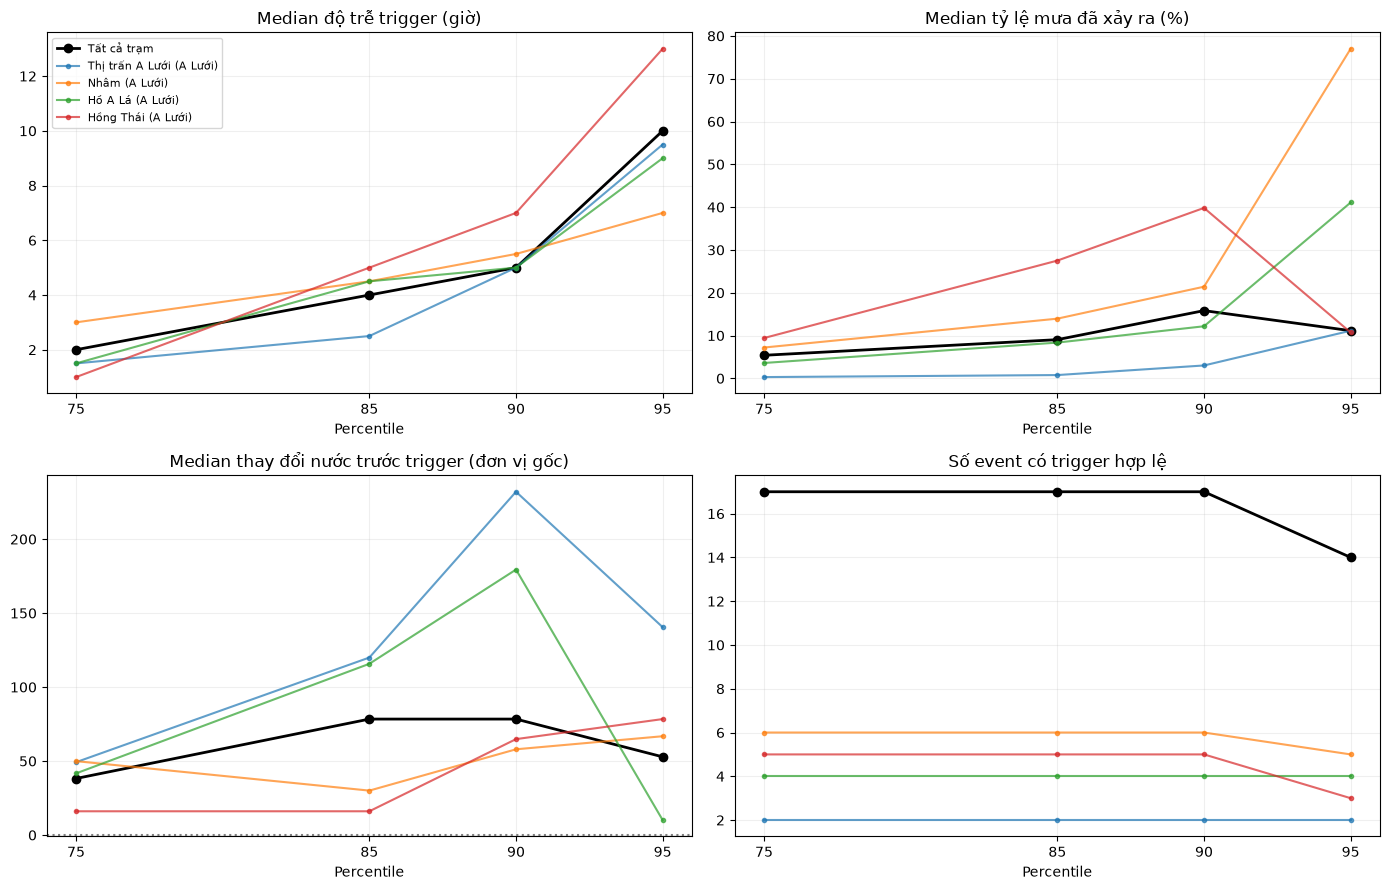

In [2]:
# Các đường theo trạm giúp thấy khác biệt mà median chung có thể che khuất.
comparison_metrics = [
    ("median_trigger_delay_hours", "Median độ trễ trigger (giờ)"),
    ("median_rain_fraction_before_trigger", "Median tỷ lệ mưa đã xảy ra (%)"),
    ("median_water_change_before_trigger", "Median thay đổi nước trước trigger (đơn vị gốc)"),
    ("valid_trigger_count", "Số event có trigger hợp lệ"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (metric, title) in zip(axes.flat, comparison_metrics):
    scale = 100 if metric == "median_rain_fraction_before_trigger" else 1
    ax.plot(percentile_summary["percentile"], percentile_summary[metric] * scale,
            color="black", marker="o", linewidth=2, label="Tất cả trạm")
    for station, subset in station_percentile_summary.groupby("station"):
        ax.plot(subset["percentile"], subset[metric] * scale,
                marker=".", alpha=0.7, label=station.split(" — ")[1])
    ax.set_title(title)
    ax.set_xlabel("Percentile")
    ax.set_xticks(trigger_percentiles)
    ax.grid(alpha=0.2)
    if metric == "median_water_change_before_trigger":
        ax.axhline(0, color="gray", linestyle=":")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


### Nhận xét so sánh các percentile

| Percentile | Event có trigger | Đủ dữ liệu 48h | Median độ trễ | Median tỷ lệ mưa trước trigger | Median thay đổi nước trước trigger (đơn vị gốc) | Median đến peak |
|---|---:|---:|---:|---:|---:|---:|
| P75 | 17 | 14 | 2h | 5,39% | 38,22 | 40h |
| P85 | 17 | 14 | 4h | 9,04% | 78,38 | 36,5h |
| P90 | 17 | 14 | 5h | 15,83% | 78,38 | 35,5h |
| P95 | 14 | 11 | 10h | 11,14% | 52,85 | 28h |

**P95 loại bỏ 3 event**, nên tỷ lệ mưa median thấp hơn P90 không có nghĩa P95 trigger sớm hơn. Trên **cùng 11 event đủ dữ liệu ở cả bốn ngưỡng**, median độ trễ lần lượt là **2 / 5 / 6 / 13h**; median tỷ lệ mưa trước trigger là **0,78 / 2,00 / 4,81 / 10,74%**. Bảng `shared_percentile_summary` cho phép so sánh mà không thay đổi nhóm event.

1. **P75 có thể quá sớm với đợt kéo dài.** Ngưỡng chỉ khoảng 2,6–3,6 đơn vị gốc/6h. Ở Hồng Thái tháng 11/2025, trigger xảy ra khi mới có 0,61% tổng mưa, sớm hơn P85 tới 18h; peak vẫn nằm ở cuối cửa sổ 48h. Nhưng chưa thể gọi mọi trigger P75 là quá sớm: đây chỉ là các event đã được chọn là đáng kể, không có đánh giá trigger sai ở các đợt mưa nhỏ khác.
2. **P95 quá muộn trong một số event.** Hồ A Lá tháng 12/2025 trigger sau 40h, khi 91,94% lượng mưa đã xảy ra. Nhâm ở event bắt đầu ngày 20/9/2026 trigger sau 24h, khi 85,39% mưa đã xảy ra và nước đã tăng 173,70 đơn vị gốc so với event_start; chỉ còn 2h đến peak. Nhâm ngày 19/9 cũng đã có 90,16% mưa trước trigger. Median toàn bộ event che khuất các trường hợp này.
3. **P85 là lựa chọn tạm thời hợp lý hơn để tiếp tục exploratory analysis.** Nó giữ đủ 17 event và trì hoãn hơn P75, nhưng thường bỏ qua ít mưa hơn P90/P95. Với Hồ A Lá tháng 12, P85 trigger sau 16h khi đã có 14,71% mưa; P90 là 18h và 21,37%. P90 vẫn đáng so sánh nếu muốn đợi mưa rõ hơn, nhưng không tốt hơn ở mọi event: Hồng Thái ngày 19/9 đã có 96,83% mưa tại trigger P90, so với 27,51% ở P85.
4. **Thay đổi nước trước trigger không tăng đều theo percentile.** Nước có thể tăng rồi giảm giữa các mốc; ví dụ đợt tháng 9/2026, P95 rơi vào lúc nước thấp hơn event_start, sau một nhịp tăng trước đó. Giá trị nhỏ hoặc âm không chứng minh trigger chưa bỏ lỡ phản ứng nước. Cần đọc cùng tỷ lệ mưa và biểu đồ event.

Có **3 / 4 / 3 / 0** trường hợp peak nằm đúng cuối cửa sổ 48h ở P75 / P85 / P90 / P95. Peak thật có thể nằm sau cửa sổ; không chọn ngưỡng chỉ vì thời gian đến peak ngắn hơn, vì mỗi trigger dịch chuyển cả cửa sổ quan sát.

Những nhận xét này dựa trên số event ít, nhiều trạm cùng theo dõi một đợt và các cửa sổ có thể chồng lấn. P85 là một lựa chọn để khảo sát tiếp, **chưa phải ngưỡng tối ưu đã được xác nhận**, không phải ngưỡng cảnh báo lũ thực tế và không mang ý nghĩa nhân quả.
